In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def mean_relative_error(y_true, y_pred):
    """
    Calcula el error relativo medio en porcentaje.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask   = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def calculate_r2(y_true, y_pred):
    """
    Calcula el coeficiente de determinación R² usando la fórmula:
    R² = 1 - (Σ(y_true - y_pred)²) / (Σ(y_true - mean(y_true))²)
    """
    import numpy as np
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return (1 -  ss_res/ss_tot) if ss_res != 0 else 1.0

In [4]:
def plot_comparison_by_rep(merged_df, vitruve_col, video_col, title=""):
    """
    Crea un gráfico donde el eje x es la repetición y el eje y muestra los valores de la métrica.
    Se grafican dos series (Vitruve y Video) con líneas y marcadores. También incluye
    líneas de tendencia (regresión lineal) para cada serie.
    """
    rep = merged_df['repetition_index'].astype(int).values
    vitruve_y = merged_df[vitruve_col].astype(str).str.replace(',', '.').astype(float).values
    video_y   = merged_df[video_col].astype(str).str.replace(',', '.').astype(float).values

    plt.figure(figsize=(8,6))
    
    # Graficamos los datos en forma de línea con marcadores
    plt.plot(rep, vitruve_y, marker='o', color='blue', label='Vitruve', alpha=0.7)
    plt.plot(rep, video_y,   marker='s', color='red',  label='Video', alpha=0.7)
    
    # Agregamos líneas de tendencia (regresión lineal) para cada serie
    if len(rep) >= 2:
        # Tendencia para Vitruve
        m_v, b_v = np.polyfit(rep, vitruve_y, 1)
        rep_line = np.linspace(rep.min(), rep.max(), 100)
        vitruve_line = m_v * rep_line + b_v
        plt.plot(rep_line, vitruve_line, linestyle='--', color='blue',
                 label=f"Vitruve fit: y={m_v:.2f}x+{b_v:.2f}")
        
        # Tendencia para Video
        m_vid, b_vid = np.polyfit(rep, video_y, 1)
        video_line = m_vid * rep_line + b_vid
        plt.plot(rep_line, video_line, linestyle='--', color='red',
                 label=f"Video fit: y={m_vid:.2f}x+{b_vid:.2f}")

    plt.xlabel("Repetición")
    plt.ylabel("Valor de la métrica")
    plt.title(title or f"Comparación por repetición: {vitruve_col} vs {video_col}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [5]:
vitruve_columns = ['Fecha repetición', 'Nº Serie', 'Nº Repetición', 'Tipo*', 'VMP (m/s)', 'Velocidad máxima (m/s)', 'ROM (cm)']
video_columns = ['repetition', 'rep_time','ROM (cm)', 'VMED (m/s)', 'VMAX (m/s)']

vitruve_path_1 = '../data/TEST_24-03-2025.csv'
vitruve_path_2 = '../data/TEST_27-03-2025.csv'
vitruve_path_3 = '../data/TEST_28-03-2025.csv'


In [6]:
metrics = [
    ('Vitruve_VMED', 'Video_VMED'),
    ('Vitruve_VMAX', 'Video_VMAX'),
    ('Vitruve_ROM',  'Video_ROM')]

In [7]:
df_vitruve = pd.read_csv(vitruve_path_2, skiprows=1)

# Squat

the reps count measured in video is: 20
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.0296
 MAE: 0.1439
 MRE: 11.64%

 R²: -0.2367

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.0813
 MAE: 0.2224
 MRE: 13.44%

 R²: -14.9237

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 16.1627
 MAE: 3.2863
 MRE: 7.22%

 R²: -1.5511



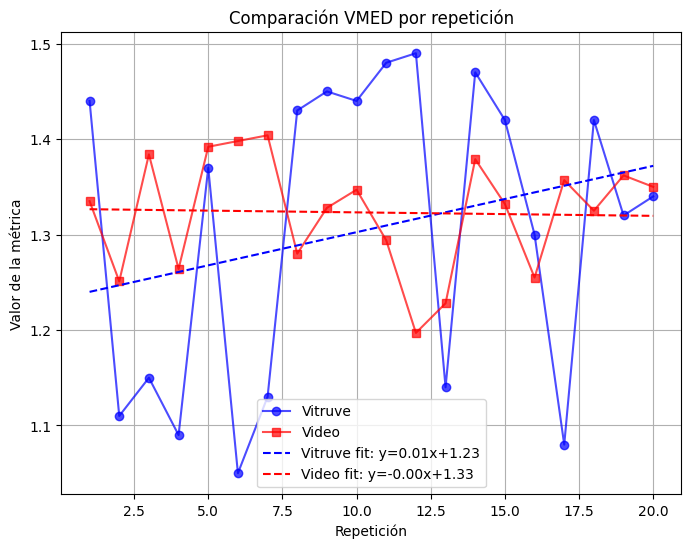

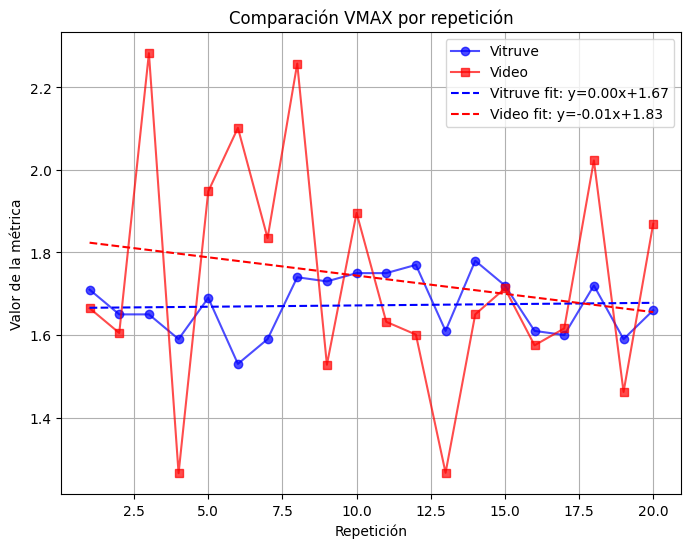

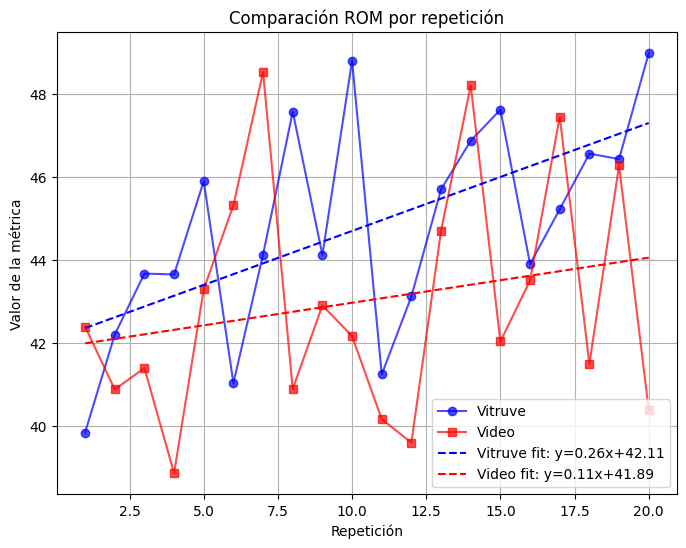

Ratio VMED (Vitruve/Video) = 0.9870758068173232
Ratio VMAX (Vitruve/Video) = 0.9611128675308251
Ratio ROM (Vitruve/Video) = 1.041965622977506


In [8]:
df_squats_vitrube = df_vitruve[df_vitruve['Tipo*']=='C'][(df_vitruve['Nº Serie'].isin([3,4]))][df_vitruve['Nº Repetición']!=11][vitruve_columns].reset_index()
df_squats_vitrube['repetition_index'] = range(1, len(df_squats_vitrube) + 1)


df_squat_lat1 = pd.read_csv('../data_export/squat/20250404_080407_squat_metrics.csv')
df_squat_lat2 = pd.read_csv('../data_export/squat/20250404_080837_squat_metrics.csv')
df_video_squat_lat = pd.concat([df_squat_lat1, df_squat_lat2], ignore_index=True)
df_video_squat_lat['repetition_index'] = range(1, len(df_video_squat_lat) + 1)
print(f"the reps count measured in video is: {df_video_squat_lat.shape[0]}")

df_squats_vitrube.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_squat_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)
squat_lat_df = pd.merge(df_squats_vitrube, df_video_squat_lat, on='repetition_index', how='inner')


for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = squat_lat_df[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = squat_lat_df[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(squat_lat_df, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(squat_lat_df, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(squat_lat_df, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = squat_lat_df[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = squat_lat_df[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = squat_lat_df[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

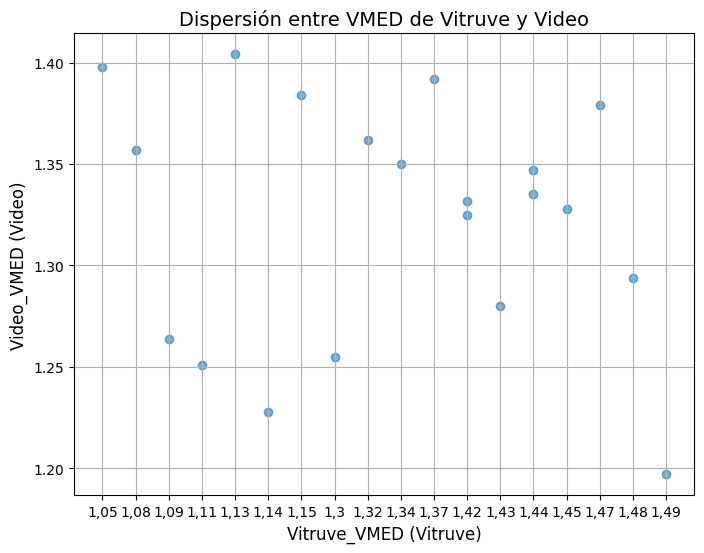

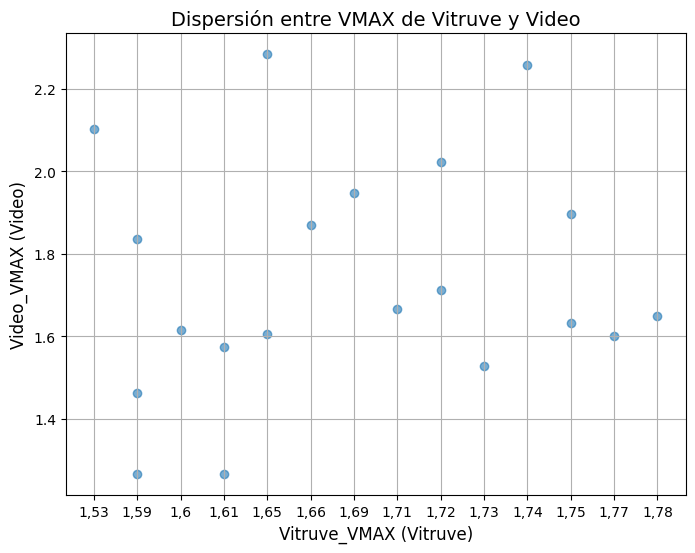

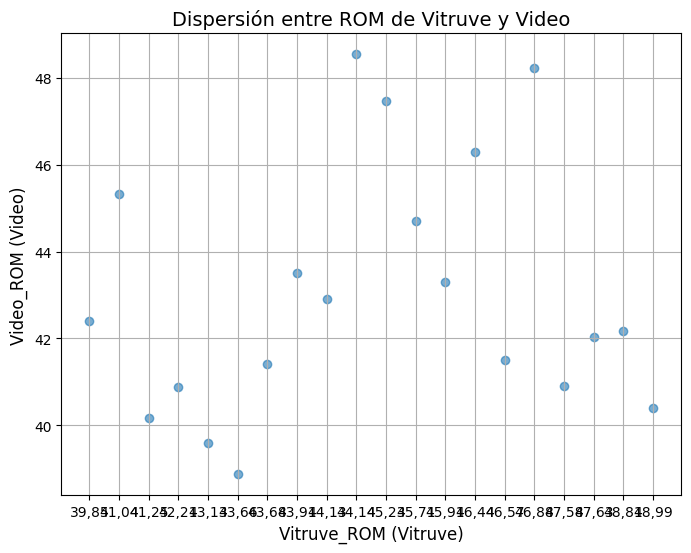

In [11]:
def plot_scatter_ordered(df, vitruve_col, video_col, title):
    # Ordenar el DataFrame por las mediciones de Vitruve (eje X)
    df_sorted = df.sort_values(by=vitruve_col)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(df_sorted[vitruve_col], df_sorted[video_col], alpha=0.6)
    plt.xlabel(f'{vitruve_col} (Vitruve)', fontsize=12)
    plt.ylabel(f'{video_col} (Video)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True)
    plt.show()


# Gráfico para VMED
plot_scatter_ordered(squat_lat_df, 'Vitruve_VMED', 'Video_VMED', "Dispersión entre VMED de Vitruve y Video")

# Gráfico para VMAX
plot_scatter_ordered(squat_lat_df, 'Vitruve_VMAX', 'Video_VMAX', "Dispersión entre VMAX de Vitruve y Video")

# Gráfico para ROM
plot_scatter_ordered(squat_lat_df, 'Vitruve_ROM', 'Video_ROM', "Dispersión entre ROM de Vitruve y Video")


# Curl

## Vista lateral

the reps count measured in video is: 20
the reps count measured in vitruve is: 20
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.0760
 MAE: 0.2145
 MRE: 22.04%

 R²: -3.3758

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.1021
 MAE: 0.2888
 MRE: 16.13%

 R²: -6.4808

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 31.5259
 MAE: 4.6973
 MRE: 8.59%

 R²: -12.1861



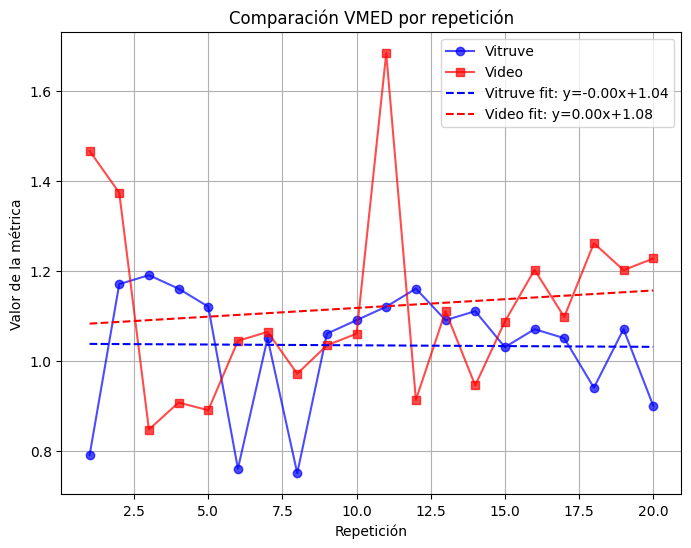

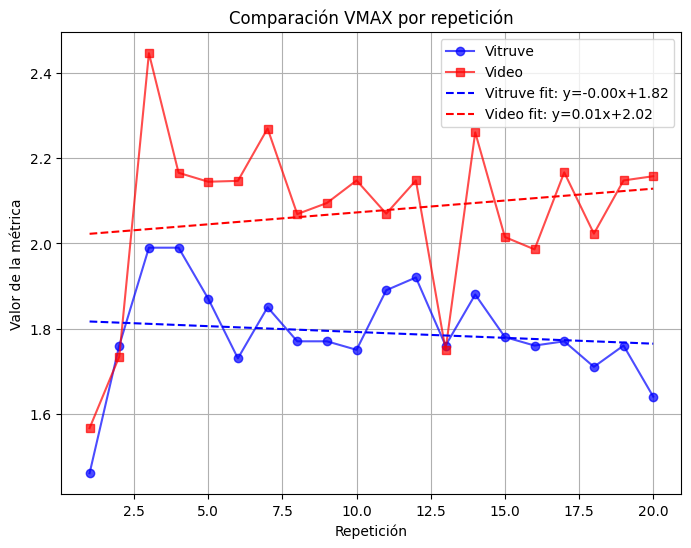

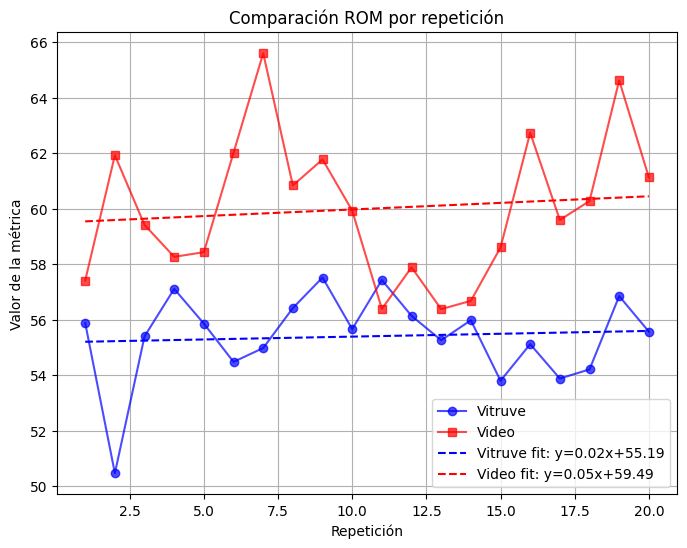

Ratio VMED (Vitruve/Video) = 0.9239567509605934
Ratio VMAX (Vitruve/Video) = 0.8626213475296892
Ratio ROM (Vitruve/Video) = 0.923440805012493


In [26]:
df_curl_lat1 = pd.read_csv('../data_export/curl/20250404_081733_curl_metrics.csv')
df_curl_lat2 = pd.read_csv('../data_export/curl/20250404_082141_curl_metrics.csv')
df_video_curl_lat = pd.concat([df_curl_lat1, df_curl_lat2], ignore_index=True)
df_video_curl_lat['repetition_index'] = range(1, len(df_video_curl_lat) + 1)
print(f"the reps count measured in video is: {df_video_curl_lat.shape[0]}")

df_vitruve_curl_lat =  df_vitruve[df_vitruve['Nº Serie'].isin([5,6])][df_vitruve['Tipo*']=='C']
df_vitruve_curl_lat['repetition_index'] = range(1, len(df_vitruve_curl_lat) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_curl_lat.shape[0]}")


df_vitruve_curl_lat.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_curl_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_curl_lat = pd.merge(df_vitruve_curl_lat, df_video_curl_lat, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_curl_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_curl_lat[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_curl_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_curl_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_curl_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_curl_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_curl_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_curl_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

## Vista frontal

the reps count measured in video is: 20
the reps count measured in vitruve is: 20
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.6931
 MAE: 0.7538
 MRE: 70.25%

 R²: -116.6678

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 2.1768
 MAE: 1.4710
 MRE: 81.13%

 R²: -166.8472

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 970.2112
 MAE: 30.4580
 MRE: 55.86%

 R²: -446.9131



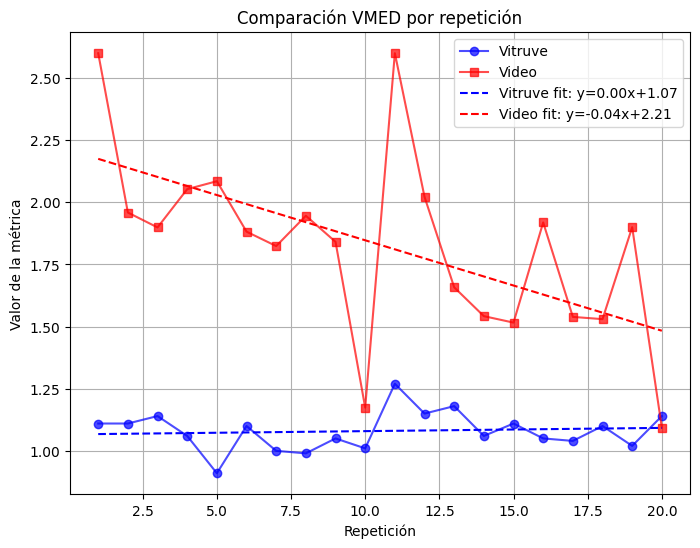

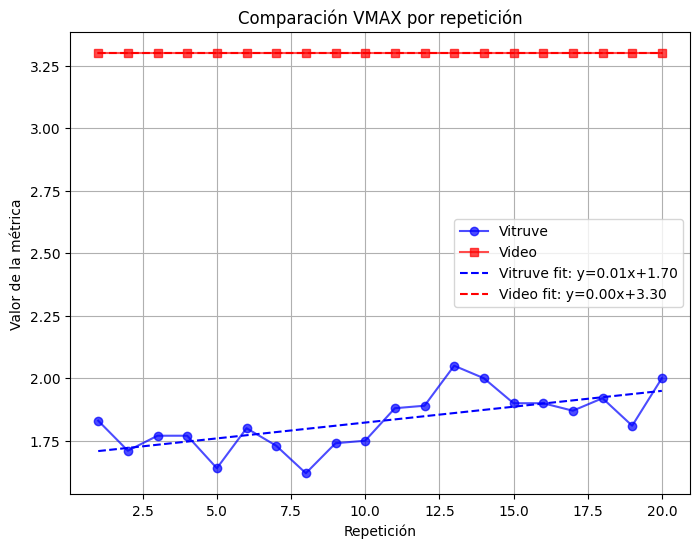

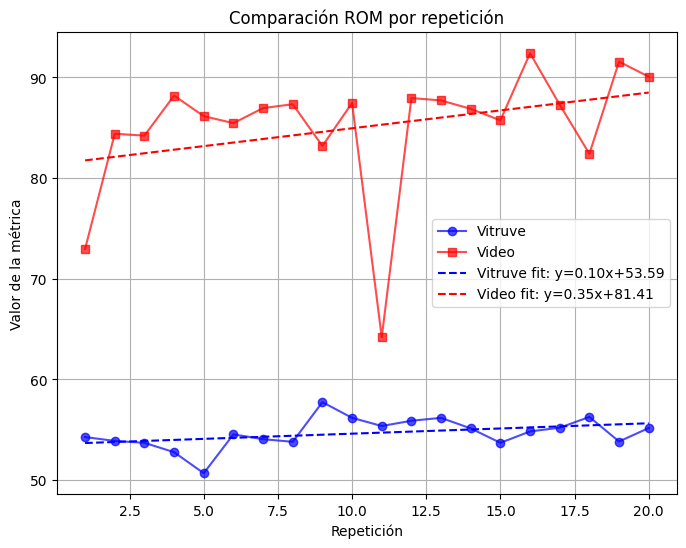

Ratio VMED (Vitruve/Video) = 0.5904543217976055
Ratio VMAX (Vitruve/Video) = 0.5542424242424244
Ratio ROM (Vitruve/Video) = 0.6422097560202025


In [27]:
df_curl_front1 = pd.read_csv('../data_export/curl/20250404_083201_curl_metrics.csv')
df_curl_front2 = pd.read_csv('../data_export/curl/20250404_083607_curl_metrics.csv')
df_video_curl_front = pd.concat([df_curl_front1, df_curl_front2], ignore_index=True)
df_video_curl_front['repetition_index'] = range(1, len(df_video_curl_front) + 1)
print(f"the reps count measured in video is: {df_video_curl_front.shape[0]}")

df_vitruve_curl_front =  df_vitruve[df_vitruve['Nº Serie'].isin([7,8])][df_vitruve['Tipo*']=='C']
df_vitruve_curl_front['repetition_index'] = range(1, len(df_vitruve_curl_front) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_curl_front.shape[0]}")



df_vitruve_curl_front.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_curl_front.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_curl_front = pd.merge(df_video_curl_front, df_vitruve_curl_front, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_curl_front[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_curl_front[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_curl_front, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_curl_front, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_curl_front, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_curl_front[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_curl_front[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_curl_front[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)


# Flexiones

## Vista lateral

the reps count measured in video is: 28
the reps count measured in vitruve is: 28
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.0067
 MAE: 0.0659
 MRE: 12.03%

 R²: -0.1389

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.0221
 MAE: 0.1164
 MRE: 12.07%

 R²: -5.4770

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 5.3530
 MAE: 1.7647
 MRE: 8.00%

 R²: -3.1050



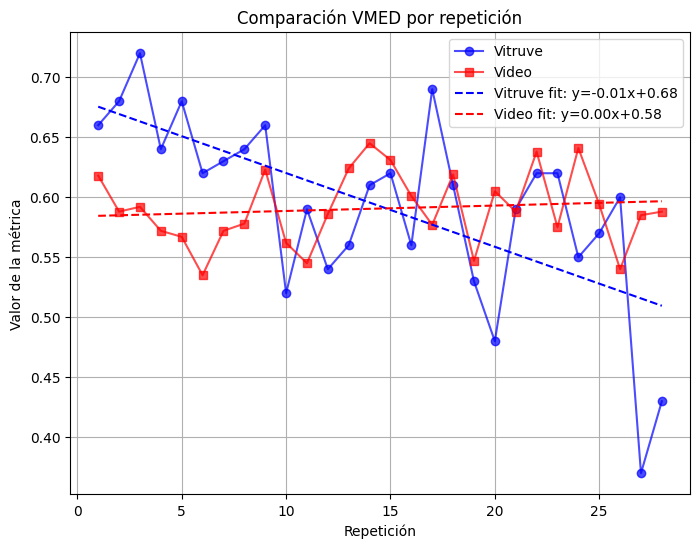

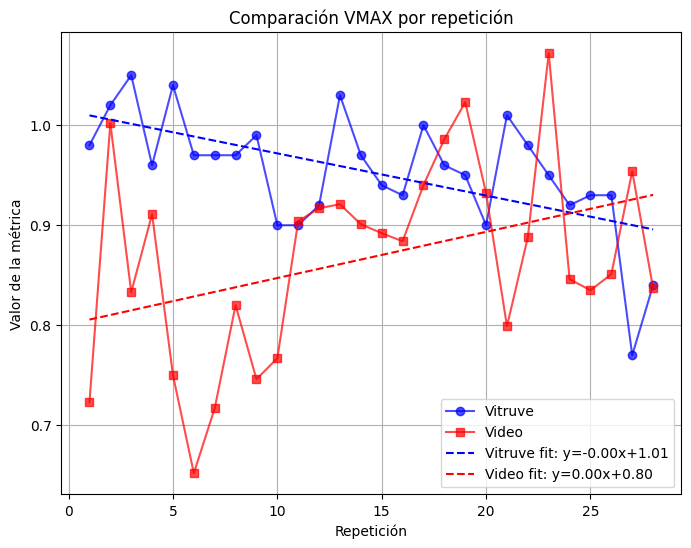

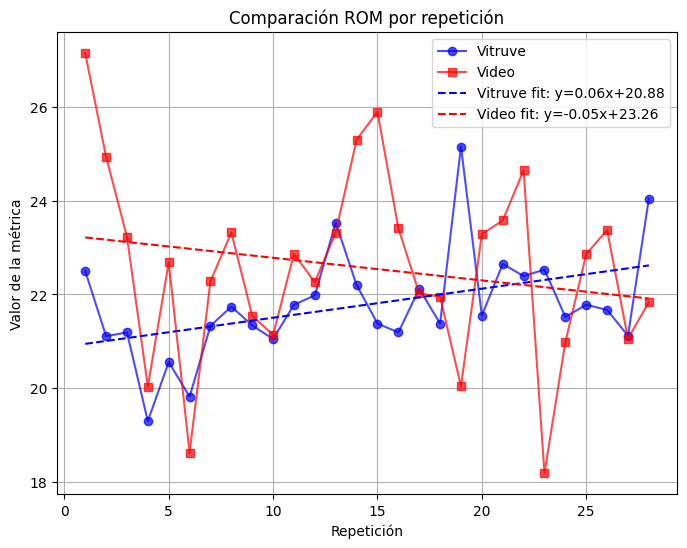

Ratio VMED (Vitruve/Video) = 1.003265602322206
Ratio VMAX (Vitruve/Video) = 1.097806855120767
Ratio ROM (Vitruve/Video) = 0.9653569953164594


In [28]:
df_pushup_lat1 = pd.read_csv('../data_export/pushup/20250404_090852_pushup_metrics.csv')
df_pushup_lat2 =  pd.read_csv('../data_export/pushup/20250404_091535_pushup_metrics.csv')
df_video_pushup_lat = pd.concat([df_pushup_lat1, df_pushup_lat2], ignore_index=True)
df_video_pushup_lat['repetition_index'] = range(1, len(df_video_pushup_lat) + 1)
print(f"the reps count measured in video is: {df_video_pushup_lat.shape[0]}")

df_vitruve_pushup_lat =  df_vitruve[df_vitruve['Nº Serie'].isin([13,14])][df_vitruve['Tipo*']=='C']
df_vitruve_pushup_lat['repetition_index'] = range(1, len(df_vitruve_pushup_lat) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_pushup_lat.shape[0]}")



df_vitruve_pushup_lat.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_pushup_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_pushup_lat = pd.merge(df_video_pushup_lat, df_vitruve_pushup_lat, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_pushup_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_pushup_lat[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_pushup_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_pushup_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_pushup_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_pushup_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_pushup_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_pushup_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

## Vista frontal

the reps count measured in video is: 25
the reps count measured in vitruve is: 20
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.1918
 MAE: 0.4070
 MRE: 37.30%

 R²: -31.5572

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.7594
 MAE: 0.8567
 MRE: 46.71%

 R²: -57.5515

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 955.3883
 MAE: 30.7257
 MRE: 56.18%

 R²: -440.0699



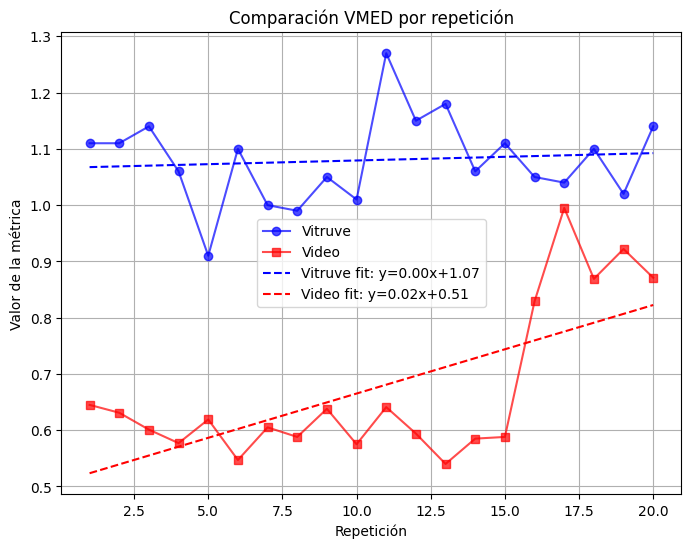

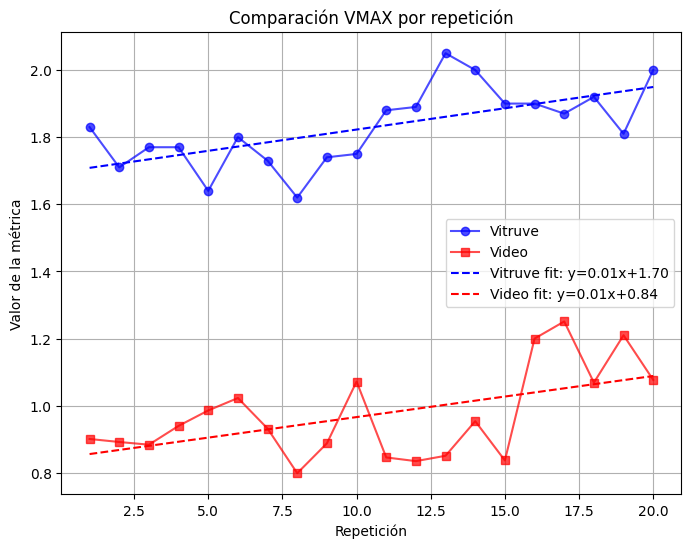

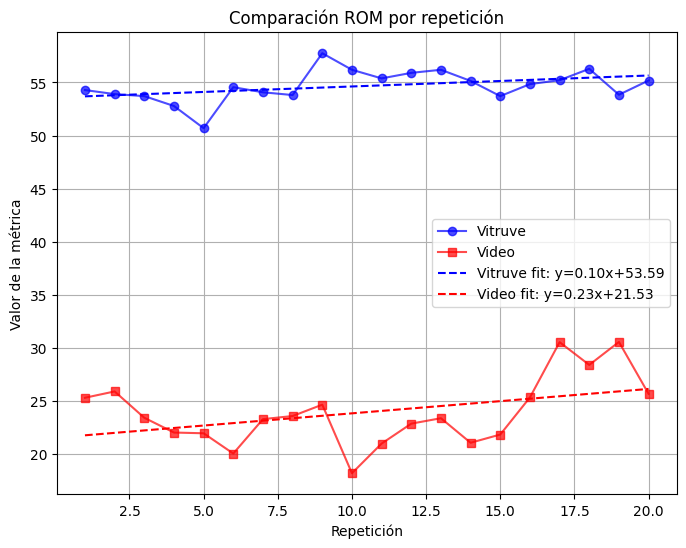

Ratio VMED (Vitruve/Video) = 1.6047548291233287
Ratio VMAX (Vitruve/Video) = 1.8810099244099345
Ratio ROM (Vitruve/Video) = 2.2832108618525875


In [29]:
df_pushup_front1 = pd.read_csv('../data_export/pushup/20250404_091125_pushup_metrics.csv')
df_pushup_front2 = pd.read_csv('../data_export/pushup/20250404_092233_pushup_metrics.csv')
df_video_pushup_front = pd.concat([df_pushup_front1, df_pushup_front2], ignore_index=True)
df_video_pushup_front['repetition_index'] = range(1, len(df_video_pushup_front) + 1)
print(f"the reps count measured in video is: {df_video_pushup_front.shape[0]}")

df_vitruve_pushup_front =  df_vitruve[df_vitruve['Nº Serie'].isin([7,8])][df_vitruve['Tipo*']=='C']
df_vitruve_pushup_front['repetition_index'] = range(1, len(df_vitruve_pushup_front) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_pushup_front.shape[0]}")



df_vitruve_pushup_front.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_pushup_front.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_pushup_front = pd.merge(df_vitruve_pushup_front, df_video_pushup_front, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_pushup_front[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_pushup_front[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_pushup_front, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_pushup_front, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_pushup_front, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_pushup_front[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_pushup_front[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_pushup_front[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)


# Peso muerto

## Vista lateral

In [28]:
df_deadlift_lat1 = pd.read_csv('../data_export/deadlift/20250404_113400_deadlift_metrics.csv')
df_deadlift_lat2 = pd.read_csv('../data_export/deadlift/20250404_113430_deadlift_metrics.csv')
df_video_deadlift_lat = pd.concat([df_deadlift_lat1, df_deadlift_lat2], ignore_index=True)
df_video_deadlift_lat['repetition_index'] = range(1, len(df_video_deadlift_lat) + 1)
print(f"the reps count measured in video is: {df_video_deadlift_lat.shape[0]}")

df_pushup_curl_lat =  df_vitruve[df_vitruve['Nº Serie'].isin([11,12])][df_vitruve['Tipo*']=='C']
df_pushup_curl_lat['repetition_index'] = range(1, len(df_pushup_curl_lat) + 1)
print(f"the reps count measured in vitruve is: {df_pushup_curl_lat.shape[0]}")


df_pushup_curl_lat.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_deadlift_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_deadlift_lat = pd.merge(df_pushup_curl_lat, df_video_deadlift_lat, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_deadlift_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_deadlift_lat[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_curl_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_curl_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_curl_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_deadlift_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_deadlift_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_deadlift_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

the reps count measured in video is: 21


KeyError: 'Nº Serie'

## Video 100 reps

In [19]:
df_vitruve = pd.read_csv('../data/TEST_10-04-2025.csv', skiprows=1, index_col=False)
df_vitruve.columns

Index(['Email', 'Athlete', 'Last Name', 'Exercise', 'Workout Date',
       'Repetition Date', '# Set', 'Weight (kg)', 'Comments', '# Rep.',
       'Type*', 'MPV (m/s)', 'Peak Velocity (m/s)', 'ROM (cm)',
       'Mean Power (W)', '1RM (kg)', 'Duration (ms)',
       'Time to peak velocity (ms)', 'Acceleration index (m/s²)',
       'Dynamic-isometric strength (m/s²)'],
      dtype='object')

the reps count measured in video is: 100
the reps count measured in vitruve is: 100
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.0435
 MAE: 0.1851
 MRE: 18.78%

 R²: -12.2691

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.0093
 MAE: 0.0729
 MRE: 5.07%

 R²: -0.3636

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 21.5963
 MAE: 3.2656
 MRE: 7.99%

 R²: 0.5150



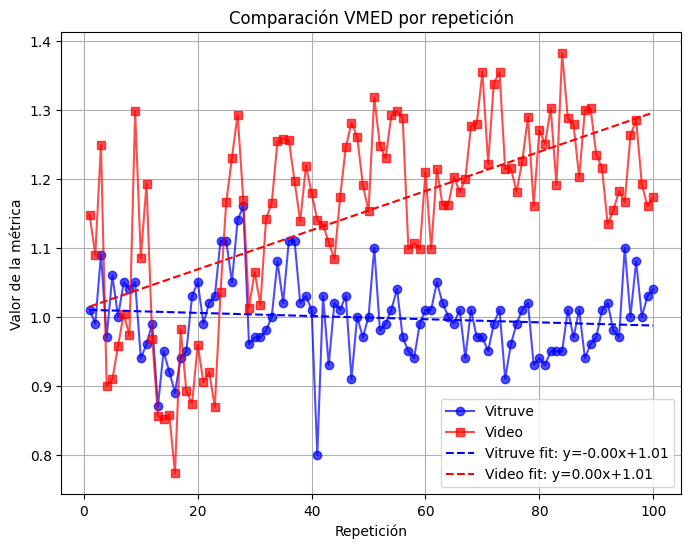

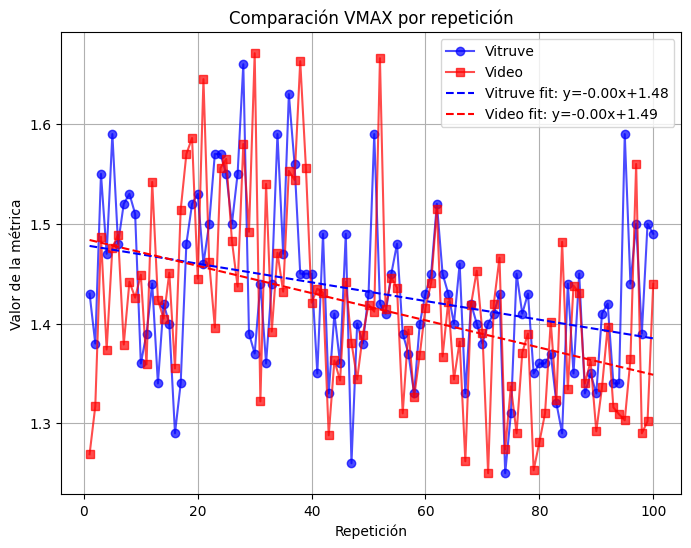

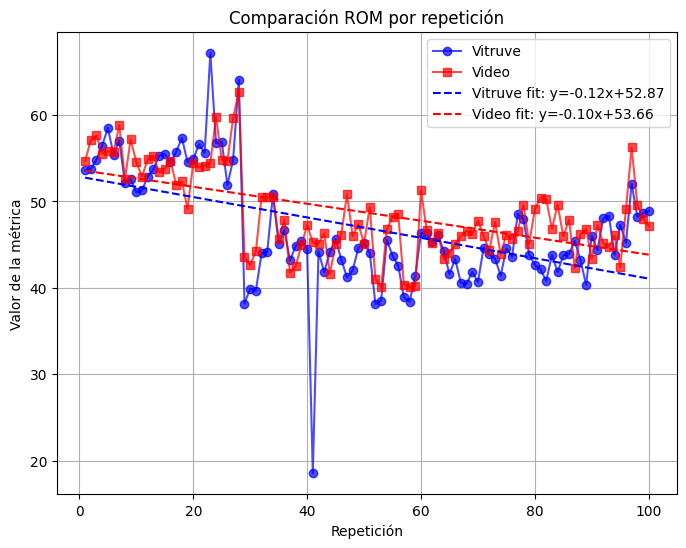

Ratio VMED (Vitruve/Video) = 0.8642926390139188
Ratio VMAX (Vitruve/Video) = 1.01077500988533
Ratio ROM (Vitruve/Video) = 0.9632317127760675


In [40]:
df_video_deadlift_lat = pd.read_csv('../data_export/deadlift/20250410_094941_deadlift_metrics.csv')
df_video_deadlift_lat['repetition_index'] = range(1, len(df_video_deadlift_lat) + 1)
df_video_deadlift_lat = df_video_deadlift_lat[df_video_deadlift_lat['repetition_index']!=51]
df_video_deadlift_lat['repetition_index'] = range(1, len(df_video_deadlift_lat) + 1)
print(f"the reps count measured in video is: {df_video_deadlift_lat.shape[0]}")

df_vitruve = pd.read_csv('../data/TEST_10-04-2025.csv', skiprows=1, index_col=False)
df_deadlift_lat =  df_vitruve[df_vitruve['# Set'].isin([33,34])][df_vitruve['Type*']=='C']
df_deadlift_lat['repetition_index'] = range(1, len(df_deadlift_lat) + 1)
print(f"the reps count measured in vitruve is: {df_deadlift_lat.shape[0]}")


df_deadlift_lat.rename(columns={
    'MPV (m/s)': 'Vitruve_VMED',
    'Peak Velocity (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_deadlift_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_deadlift_lat = pd.merge(df_deadlift_lat, df_video_deadlift_lat, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_deadlift_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_deadlift_lat[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_deadlift_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_deadlift_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_deadlift_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_deadlift_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_deadlift_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_deadlift_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

No es capaz de realizar la detección de 1 o más series

# Pajaro banco

## Vista frontal

## Vista lateral

the reps count measured in video is: 20
the reps count measured in vitruve is: 20
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.0489
 MAE: 0.1802
 MRE: 8.26%

 R²: -3.4709

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.1067
 MAE: 0.2725
 MRE: 9.84%

 R²: -13.9760

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 65.0254
 MAE: 6.5534
 MRE: 7.20%

 R²: -14.4493



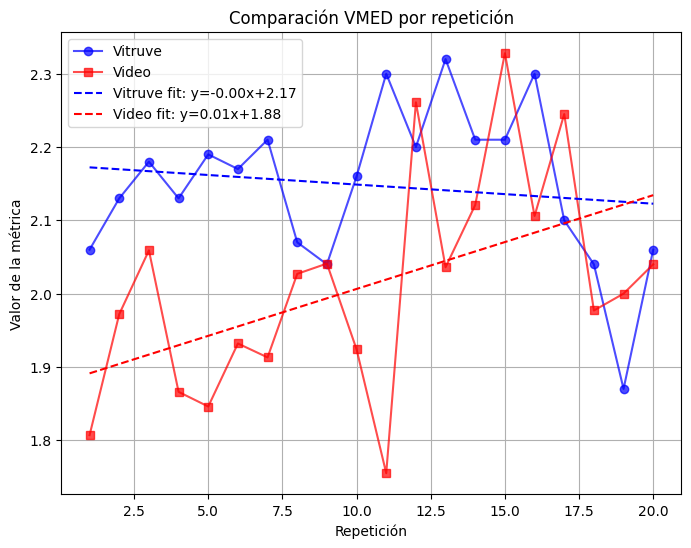

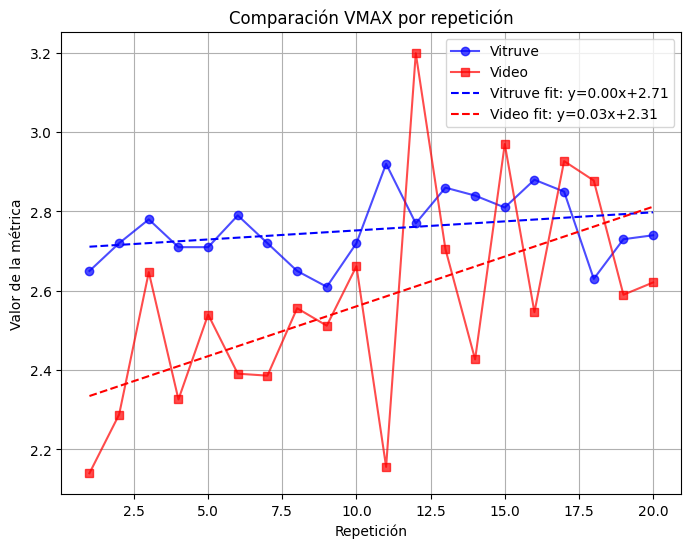

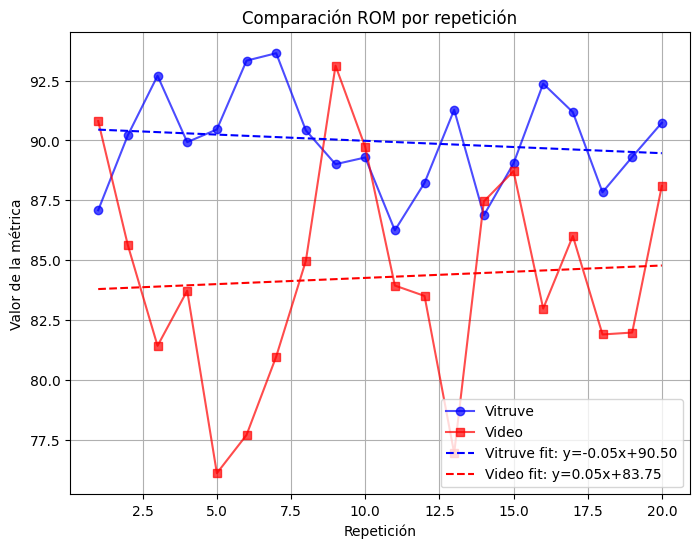

Ratio VMED (Vitruve/Video) = 1.0669217011128778
Ratio VMAX (Vitruve/Video) = 1.0703946217964908
Ratio ROM (Vitruve/Video) = 1.067249640831444


In [8]:
df_reversefly_lat1 = pd.read_csv('../data_export/reverse_fly/20250404_114704_reverse_fly_metrics.csv')
df_reversefly_lat2 = pd.read_csv('../data_export/reverse_fly/20250404_114755_reverse_fly_metrics.csv')
df_video_reversefly_lat = pd.concat([df_reversefly_lat1, df_reversefly_lat2], ignore_index=True)
df_video_reversefly_lat['repetition_index'] = range(1, len(df_video_reversefly_lat) + 1)
print(f"the reps count measured in video is: {df_video_reversefly_lat.shape[0]}")

df_reversefly_curl_lat =  df_vitruve[df_vitruve['Nº Serie'].isin([1,2])][df_vitruve['Tipo*']=='C']
df_reversefly_curl_lat['repetition_index'] = range(1, len(df_reversefly_curl_lat) + 1)
print(f"the reps count measured in vitruve is: {df_reversefly_curl_lat.shape[0]}")


df_reversefly_curl_lat.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_reversefly_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_reversefly_lat = pd.merge(df_video_reversefly_lat, df_reversefly_curl_lat, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_reversefly_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_reversefly_lat[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_reversefly_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_reversefly_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_reversefly_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_reversefly_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_reversefly_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_reversefly_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

In [9]:
vitruve_mean_rom

89.9605

In [10]:
video_mean_rom

84.2919

# Extension triceps tras nuca

## Vista lateral

the reps count measured in video is: 29
the reps count measured in vitruve is: 27
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.6334
 MAE: 0.6839
 MRE: 41.65%

 R²: -10.1782

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.5620
 MAE: 0.5372
 MRE: 23.93%

 R²: -12.2721

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 461.7026
 MAE: 17.4402
 MRE: 40.73%

 R²: -3.8522



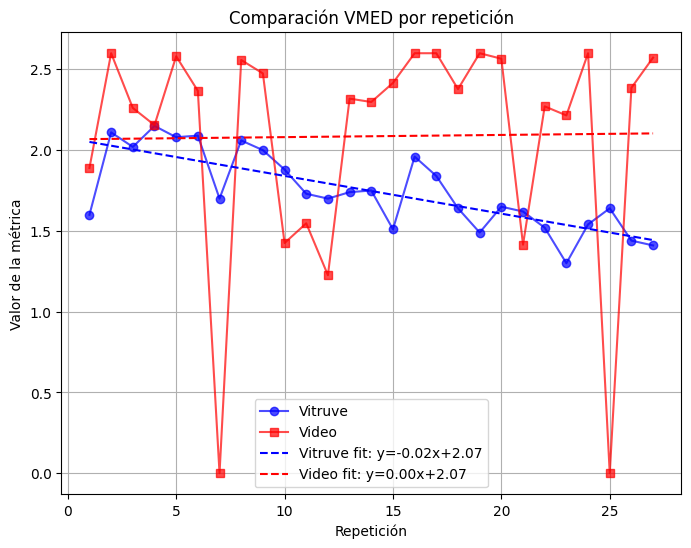

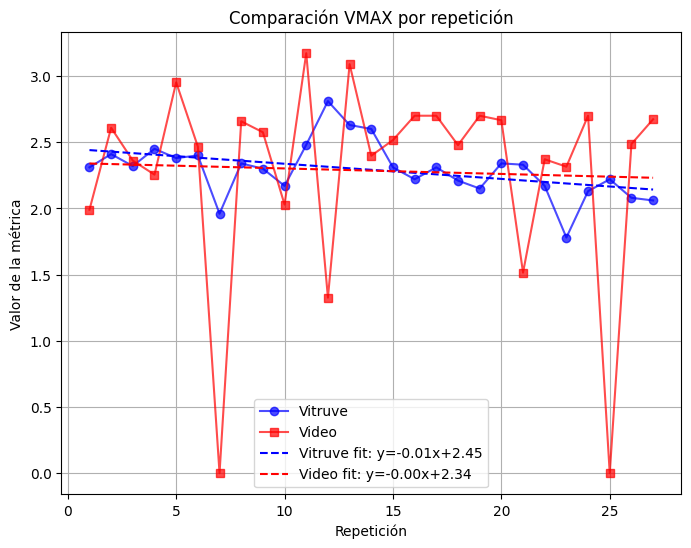

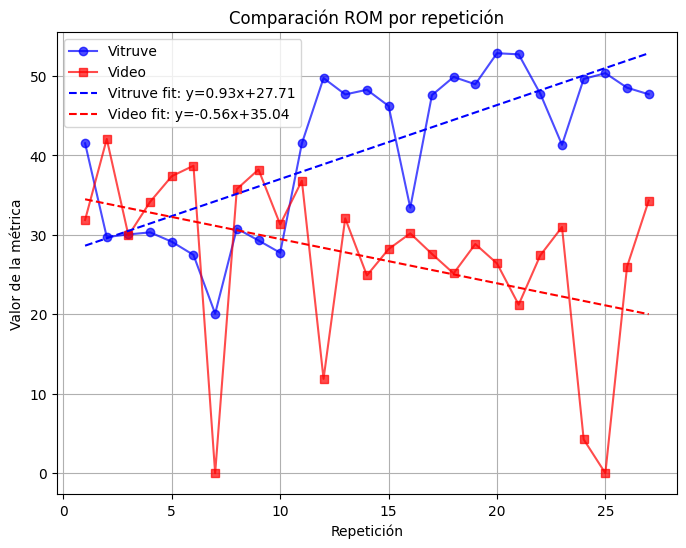

Ratio VMED (Vitruve/Video) = 0.8375057703916764
Ratio VMAX (Vitruve/Video) = 1.0027390155751124
Ratio ROM (Vitruve/Video) = 1.4955882592787908


In [32]:
df_vitruve = pd.read_csv(vitruve_path_3, skiprows=1)
df_extension_lat1 = pd.read_csv('../data_export/overhead_triceps/20250404_122608_overhead_triceps_metrics.csv')
df_extension_lat2 = pd.read_csv('../data_export/overhead_triceps/20250404_122747_overhead_triceps_metrics.csv')
df_video_extension_lat = pd.concat([df_extension_lat1, df_extension_lat2], ignore_index=True)
df_video_extension_lat['repetition_index'] = range(1, len(df_video_extension_lat) + 1)
print(f"the reps count measured in video is: {df_video_extension_lat.shape[0]}")

df_vitruve_ext_lat =  df_vitruve[df_vitruve['Nº Serie'].isin([7,8])][df_vitruve['Tipo*']=='C']
df_vitruve_ext_lat['repetition_index'] = range(1, len(df_vitruve_ext_lat) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_ext_lat.shape[0]}")


df_vitruve_ext_lat.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_extension_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_ext_lat = pd.merge(df_vitruve_ext_lat, df_video_extension_lat, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_ext_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_ext_lat[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_ext_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_ext_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_ext_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_ext_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_ext_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_ext_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)


In [33]:
df_vitruve = pd.read_csv('../data/TEST_28-03-2025.csv', skiprows = 1)
df_overhead_vitrube = df_vitruve[df_vitruve['Tipo*']=='C'][(df_vitruve['Nº Serie']==7) | (df_vitruve['Nº Serie']==8)][df_vitruve['Nº Repetición']!=14][vitruve_columns].reset_index()
df_overhead_vitrube['repetition_index'] = range(1, len(df_overhead_vitrube) + 1)
df_overhead_vitrube.shape

(26, 9)

In [34]:
df_overhead_video = pd.read_csv('../data_export/overhead_triceps_metrics.csv')
df_overhead_video['repetition_index'] = range(1, len(df_overhead_video) + 1)
df_overhead_video = df_overhead_video[df_overhead_video['repetition_index']<=27][df_overhead_video['repetition']!=14]

df_overhead_video.shape

(25, 13)

In [35]:
df_overhead_vitrube.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_overhead_video.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

In [36]:
overhead_merge_df = pd.merge(df_overhead_vitrube, df_overhead_video, how = 'inner', on = 'repetition_index')
overhead_merge_df.head()

,index,Fecha repetición,Nº Serie,Nº Repetición,Tipo*,Vitruve_VMED,Vitruve_VMAX,Vitruve_ROM,repetition_index,start_datetime,...,gender,height (m),effective_length (m),min_angle (°),max_angle (°),Video_ROM,Video_VMED,Video_VMAX,rep_time,repetition
0,124,10:02:18,7,1,C,"1,6","2,31","41,53",1,2025-04-01T10:20:27.643066,...,male,1.84,0.522,102.332,149.871,28.015,1.832,1.932,1.00,1
1,126,10:02:19,7,2,C,"2,11","2,41","29,73",2,2025-04-01T10:20:42.783583,...,male,1.84,0.522,106.590,150.326,26.265,1.431,1.531,1.04,2
2,128,10:02:20,7,3,C,"2,02","2,32","30,06",3,2025-04-01T10:20:56.686050,...,male,1.84,0.522,107.822,147.498,23.676,1.274,1.374,1.04,3
3,130,10:02:22,7,4,C,"2,15","2,45","30,32",4,2025-04-01T10:21:09.530834,...,male,1.84,0.522,111.108,150.566,23.856,1.566,1.978,1.00,4
4,132,10:02:23,7,5,C,"2,08","2,38","29,14",5,2025-04-01T10:21:21.592042,...,male,1.84,0.522,104.797,148.910,26.346,1.662,1.914,0.96,5


In [37]:
for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = overhead_merge_df[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = overhead_merge_df[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    
    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")

*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.2224
 MAE: 0.4051
 MRE: 22.56%

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.2583
 MAE: 0.4313
 MRE: 18.70%

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 142.5354
 MAE: 9.9738
 MRE: 23.28%



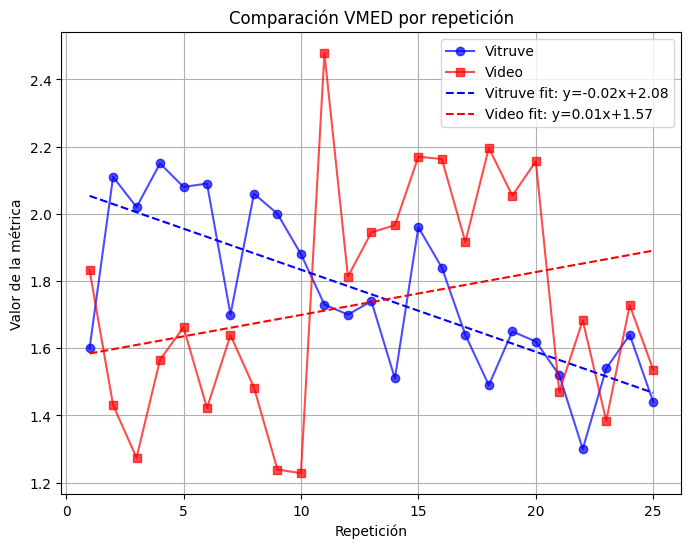

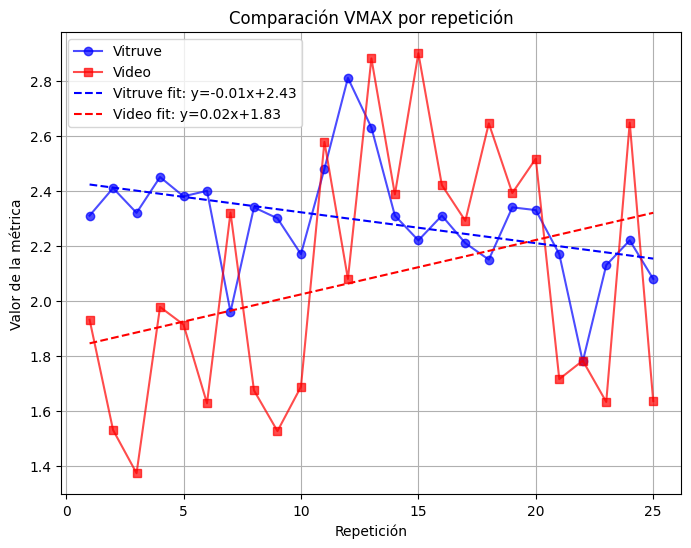

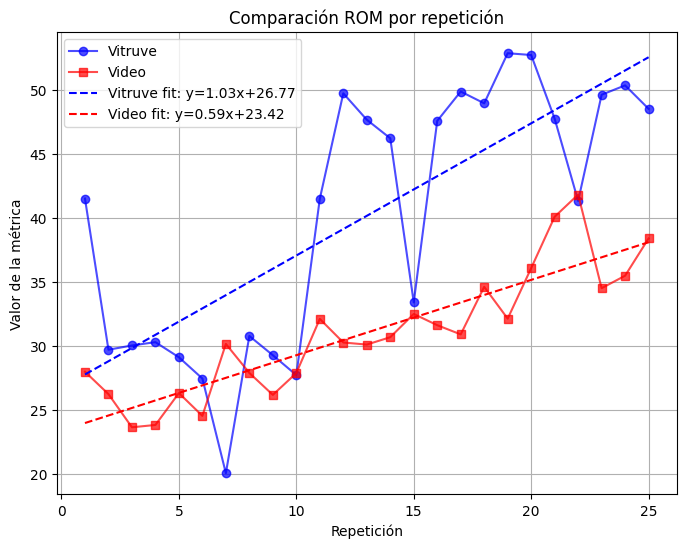

In [38]:
plot_comparison_by_rep(overhead_merge_df, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(overhead_merge_df, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(overhead_merge_df, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")

In [39]:
df_vmed = overhead_merge_df[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = overhead_merge_df[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = overhead_merge_df[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

Ratio VMED (Vitruve/Video) = 1.013238171981121
Ratio VMAX (Vitruve/Video) = 1.0985866810046856
Ratio ROM (Vitruve/Video) = 1.2934184941473403


## Vista frontal

the reps count measured in video is: 20
the reps count measured in vitruve is: 20
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.2333
 MAE: 0.4098
 MRE: 22.66%

 R²: -7.4018

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.2985
 MAE: 0.4663
 MRE: 22.02%

 R²: -15.1876

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 37.4358
 MAE: 4.8997
 MRE: 15.84%

 R²: -1.2249



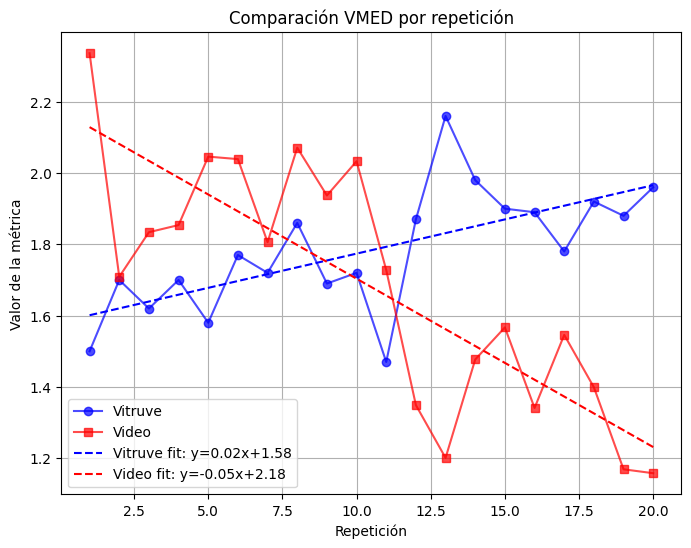

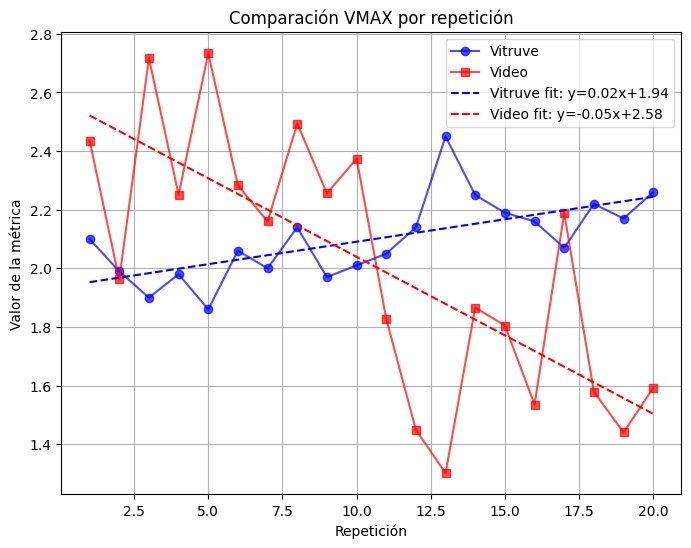

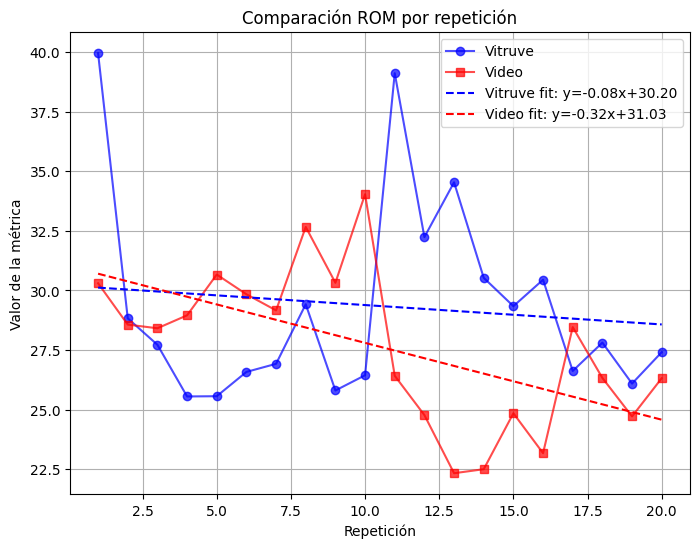

Ratio VMED (Vitruve/Video) = 1.0616071428571427
Ratio VMAX (Vitruve/Video) = 1.042707013490348
Ratio ROM (Vitruve/Video) = 1.0617920918713468


In [40]:
df_vitruve = pd.read_csv(vitruve_path_3, skiprows=1)
df_extension_front1 = pd.read_csv('../data_export/overhead_triceps/20250404_121903_overhead_triceps_metrics.csv')
df_extension_front2 = pd.read_csv('../data_export/overhead_triceps/20250404_121916_overhead_triceps_metrics.csv')
df_video_extension_front = pd.concat([df_extension_front1, df_extension_front2], ignore_index=True)
df_video_extension_front['repetition_index'] = range(1, len(df_video_extension_front) + 1)
print(f"the reps count measured in video is: {df_video_extension_front.shape[0]}")

df_vitruve_ext_front =  df_vitruve[df_vitruve['Nº Serie'].isin([5,6])][df_vitruve['Tipo*']=='C']
df_vitruve_ext_front['repetition_index'] = range(1, len(df_vitruve_ext_front) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_ext_front.shape[0]}")


df_vitruve_ext_front.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_extension_front.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_ext_front = pd.merge(df_vitruve_ext_front, df_video_extension_front, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_ext_front[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_ext_front[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_ext_front, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_ext_front, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_ext_front, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_ext_front[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_ext_front[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_ext_front[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)


# Triceps banco

## Vista frontal

the reps count measured in video is: 22
the reps count measured in vitruve is: 22
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.0685
 MAE: 0.2115
 MRE: 18.83%

 R²: -0.9130

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.0890
 MAE: 0.2215
 MRE: 14.49%

 R²: -4.8919

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 11.3078
 MAE: 2.5355
 MRE: 12.69%

 R²: -0.2321



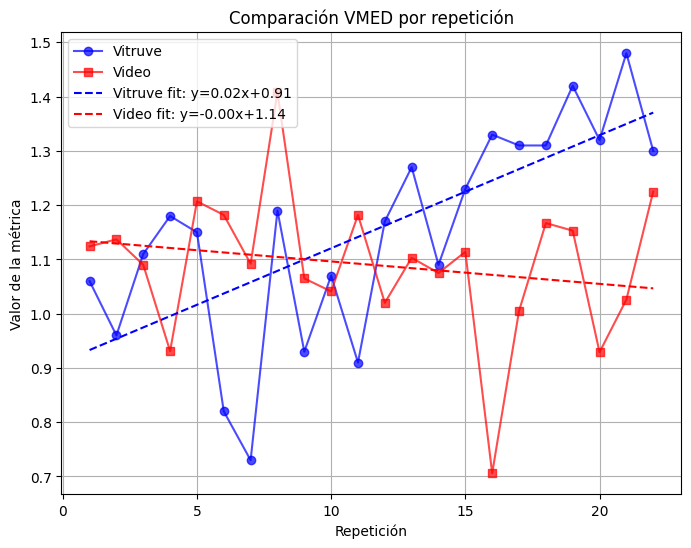

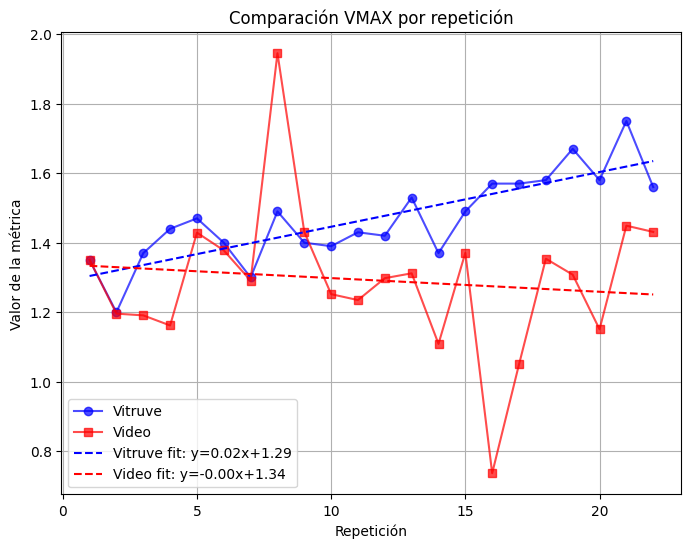

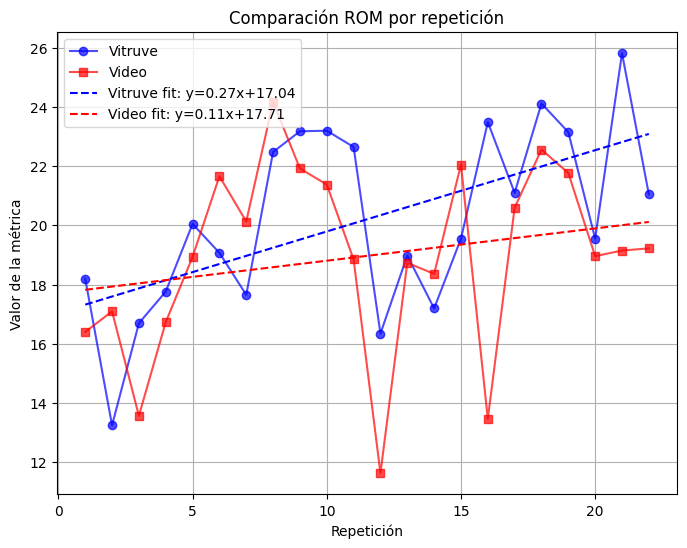

Ratio VMED (Vitruve/Video) = 1.0566258026853477
Ratio VMAX (Vitruve/Video) = 1.1371390383736062
Ratio ROM (Vitruve/Video) = 1.065215099114298


In [41]:
df_vitruve = pd.read_csv(vitruve_path_3, skiprows=1)
df_tb_front1 = pd.read_csv('../data_export/bench_dips/20250404_123616_bench_dips_metrics.csv')
df_tb_front2 = pd.read_csv('../data_export/bench_dips/20250404_123907_bench_dips_metrics.csv')
df_video_tb_front = pd.concat([df_tb_front1, df_tb_front2], ignore_index=True)
df_video_tb_front['repetition_index'] = range(1, len(df_video_tb_front) + 1)
print(f"the reps count measured in video is: {df_video_tb_front.shape[0]}")

df_vitruve_tb_front =  df_vitruve[df_vitruve['Nº Serie'].isin([9,10])][df_vitruve['Tipo*']=='C']
df_vitruve_tb_front['repetition_index'] = range(1, len(df_vitruve_tb_front) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_tb_front.shape[0]}")


df_vitruve_tb_front.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_tb_front.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_tb_front = pd.merge(df_vitruve_tb_front, df_video_tb_front, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_tb_front[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_tb_front[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_tb_front, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_tb_front, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_tb_front, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_tb_front[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_tb_front[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_tb_front[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)


In [42]:
df_vitruve = pd.read_csv('../data/TEST_28-03-2025.csv', skiprows = 1)
df_benchdips_vitrube = df_vitruve[df_vitruve['Tipo*']=='C'][(df_vitruve['Nº Serie']==9) | (df_vitruve['Nº Serie']==10)][vitruve_columns].reset_index()
df_benchdips_vitrube['repetition_index'] = range(1, len(df_benchdips_vitrube) + 1)
df_benchdips_vitrube.shape[0]

22

In [43]:
df_benchdips_video = pd.read_csv('../data_export/bench_dips_metrics.csv')
df_benchdips_video['repetition_index'] = range(1, len(df_overhead_video) + 1)

df_benchdips_video.shape[0]

ValueError: Length of values (25) does not match length of index (22)

In [ ]:
df_benchdips_vitrube.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_benchdips_video.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

In [ ]:
benchdips_merge_df = pd.merge(df_benchdips_vitrube, df_benchdips_video, how = 'inner', on = 'repetition_index')
benchdips_merge_df.head()

,index,Fecha repetición,Nº Serie,Nº Repetición,Tipo*,Vitruve_VMED,Vitruve_VMAX,Vitruve_ROM,repetition_index,start_datetime,...,gender,height (m),effective_length (m),min_angle (°),max_angle (°),Video_ROM,Video_VMED,Video_VMAX,rep_time,repetition
0,179,10:08:10,9,1,C,"1,06","1,35","18,2",1,2025-04-01T11:14:38.131963,...,male,1.84,0.409,111.296,156.257,17.391,1.192,1.432,0.32,1
1,181,10:08:12,9,2,C,"0,96","1,2","13,24",2,2025-04-01T11:14:54.437087,...,male,1.84,0.409,110.598,154.605,18.128,1.206,1.268,0.32,2
2,183,10:08:13,9,3,C,"1,11","1,37","16,69",3,2025-04-01T11:15:12.690091,...,male,1.84,0.409,113.035,148.868,14.383,1.156,1.264,0.28,3
3,185,10:08:15,9,4,C,"1,18","1,44","17,76",4,2025-04-01T11:15:30.280352,...,male,1.84,0.409,110.708,155.984,17.742,0.988,1.232,0.36,4
4,187,10:08:17,9,5,C,"1,15","1,47","20,05",5,2025-04-01T11:16:15.868780,...,male,1.84,0.409,95.551,146.105,20.080,1.281,1.516,0.36,5


In [ ]:
for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = benchdips_merge_df[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = benchdips_merge_df[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    
    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")

*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.0676
 MAE: 0.2090
 MRE: 19.40%

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.0730
 MAE: 0.1915
 MRE: 12.64%

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 10.4427
 MAE: 2.2751
 MRE: 11.76%



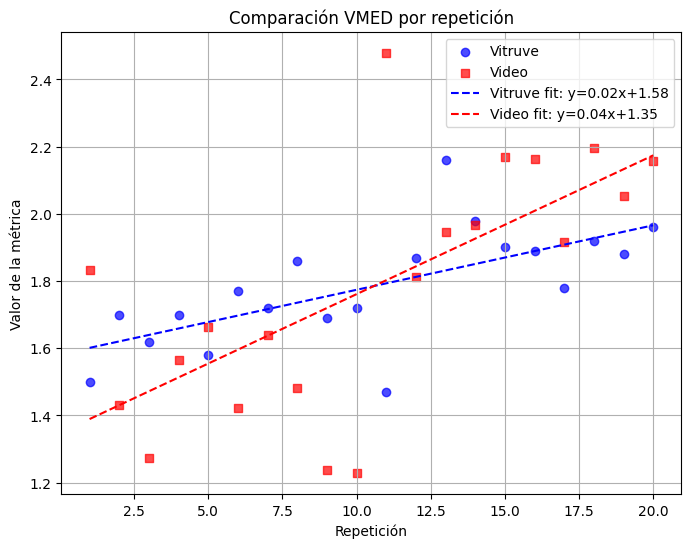

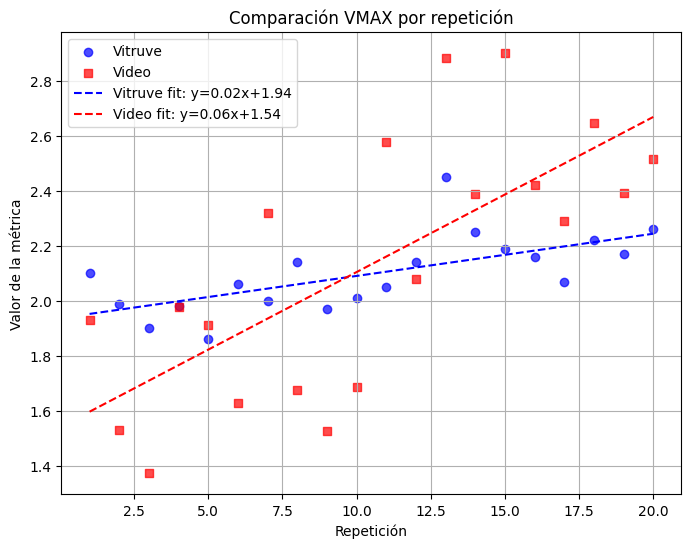

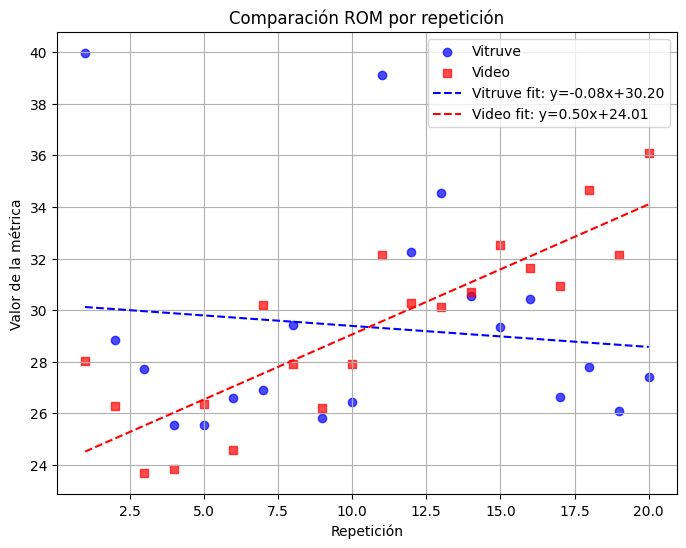

In [ ]:
plot_comparison_by_rep(overhead_merge_df, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(overhead_merge_df, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(overhead_merge_df, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")

In [ ]:
df_vmed = benchdips_merge_df[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = benchdips_merge_df[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = benchdips_merge_df[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

Ratio VMED (Vitruve/Video) = 0.9961474958723173
Ratio VMAX (Vitruve/Video) = 1.0723051409618576
Ratio ROM (Vitruve/Video) = 1.0043176780788026


## Vista lateral

the reps count measured in video is: 23
the reps count measured in vitruve is: 23
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.1293
 MAE: 0.3186
 MRE: 26.23%

 R²: -12.4680

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.0273
 MAE: 0.1327
 MRE: 9.01%

 R²: -7.5189

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 31.2363
 MAE: 5.1610
 MRE: 26.00%

 R²: -14.2466



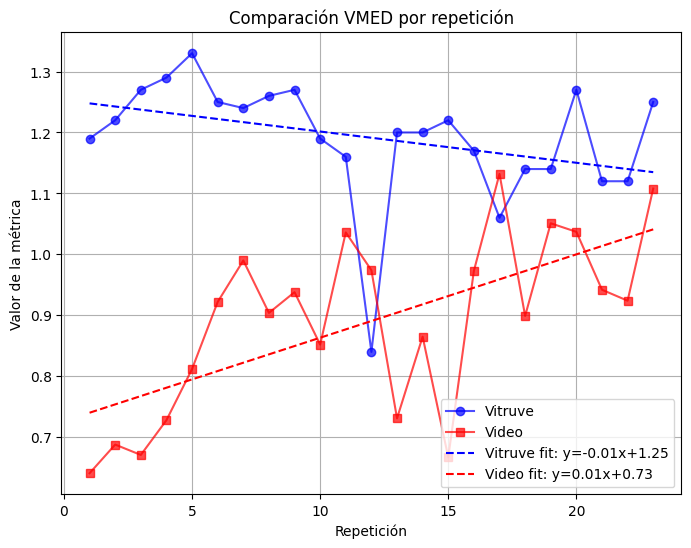

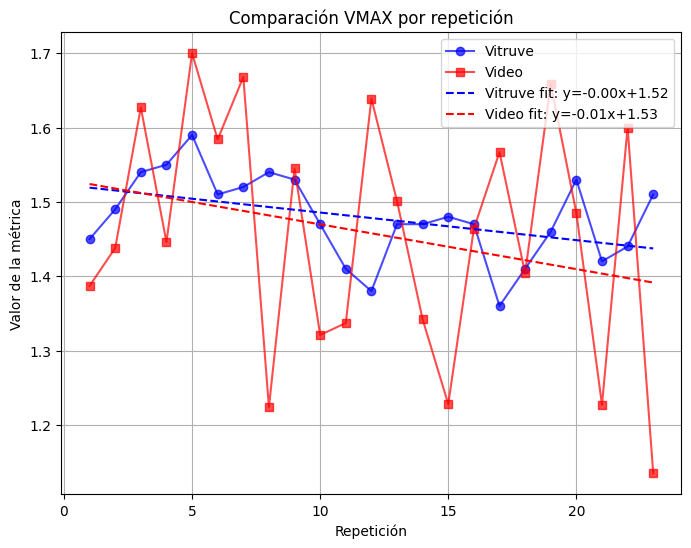

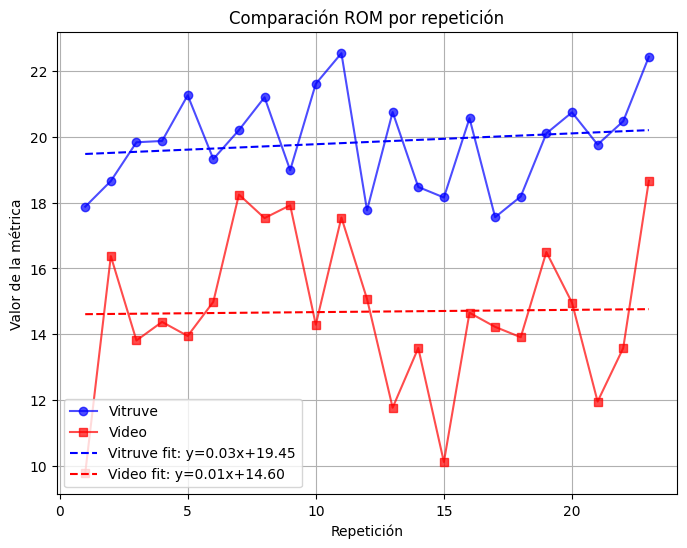

Ratio VMED (Vitruve/Video) = 1.3375640712716625
Ratio VMAX (Vitruve/Video) = 1.0140777857313292
Ratio ROM (Vitruve/Video) = 1.3514241644635367


In [ ]:
df_vitruve = pd.read_csv(vitruve_path_3, skiprows=1)
df_tb_lat1 = pd.read_csv('../data_export/bench_dips/20250404_124822_bench_dips_metrics.csv')
df_tb_lat2 = pd.read_csv('../data_export/bench_dips/20250404_124909_bench_dips_metrics.csv')
df_video_tb_lat = pd.concat([df_tb_lat1, df_tb_lat2], ignore_index=True)
df_video_tb_lat['repetition_index'] = range(1, len(df_video_tb_lat) + 1)
print(f"the reps count measured in video is: {df_video_tb_lat.shape[0]}")

df_vitruve_tb_lat =  df_vitruve[df_vitruve['Nº Serie'].isin([11,12])][df_vitruve['Tipo*']=='C']
df_vitruve_tb_lat['repetition_index'] = range(1, len(df_vitruve_tb_lat) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_tb_lat.shape[0]}")


df_vitruve_tb_lat.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_tb_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_tb_lat = pd.merge(df_vitruve_tb_lat, df_video_tb_lat, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_tb_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_tb_lat[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_tb_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_tb_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_tb_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_tb_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_tb_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_tb_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)


In [ ]:
df_vitruve = pd.read_csv('../data/TEST_28-03-2025.csv', skiprows = 1)
df_benchdips_vitrube = df_vitruve[df_vitruve['Tipo*']=='C'][(df_vitruve['Nº Serie']==11) | (df_vitruve['Nº Serie']==12)][vitruve_columns].reset_index()
df_benchdips_vitrube['repetition_index'] = range(1, len(df_benchdips_vitrube) + 1)
df_benchdips_vitrube.shape[0]

23

In [ ]:
df_benchdips_video = pd.read_csv('../data_export/bench_dips_metrics.csv')
df_benchdips_video['repetition_index'] = range(1, len(df_benchdips_video) + 1)

df_benchdips_video.shape[0]

23

In [ ]:
df_benchdips_vitrube.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_benchdips_video.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

In [ ]:
benchdips_merge_df = pd.merge(df_benchdips_vitrube, df_benchdips_video, how = 'inner', on = 'repetition_index')
benchdips_merge_df.head()

,index,Fecha repetición,Nº Serie,Nº Repetición,Tipo*,Vitruve_VMED,Vitruve_VMAX,Vitruve_ROM,repetition_index,start_datetime,...,gender,height (m),effective_length (m),min_angle (°),max_angle (°),Video_ROM,Video_VMED,Video_VMAX,rep_time,repetition
0,223,10:12:00,11,1,C,"1,19","1,45","17,88",1,2025-04-01T11:04:08.207402,...,male,1.84,0.409,117.383,146.981,9.337,0.594,1.217,0.36,1
1,225,10:12:01,11,2,C,"1,22","1,49","18,66",2,2025-04-01T11:04:22.298125,...,male,1.84,0.409,112.819,157.737,15.648,0.638,1.262,0.48,2
2,227,10:12:03,11,3,C,"1,27","1,54","19,84",3,2025-04-01T11:04:36.012895,...,male,1.84,0.409,107.691,148.316,13.196,0.621,1.428,0.48,3
3,229,10:12:04,11,4,C,"1,29","1,55","19,88",4,2025-04-01T11:04:49.510910,...,male,1.84,0.409,102.214,143.108,13.736,0.674,1.270,0.48,4
4,231,10:12:06,11,5,C,"1,33","1,59","21,27",5,2025-04-01T11:05:03.911062,...,male,1.84,0.409,107.696,148.400,13.327,0.752,1.492,0.40,5


In [ ]:
for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = benchdips_merge_df[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = benchdips_merge_df[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    
    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")

*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.1696
 MAE: 0.3718
 MRE: 30.48%

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.0557
 MAE: 0.1995
 MRE: 13.43%

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 38.0389
 MAE: 5.8127
 MRE: 29.28%



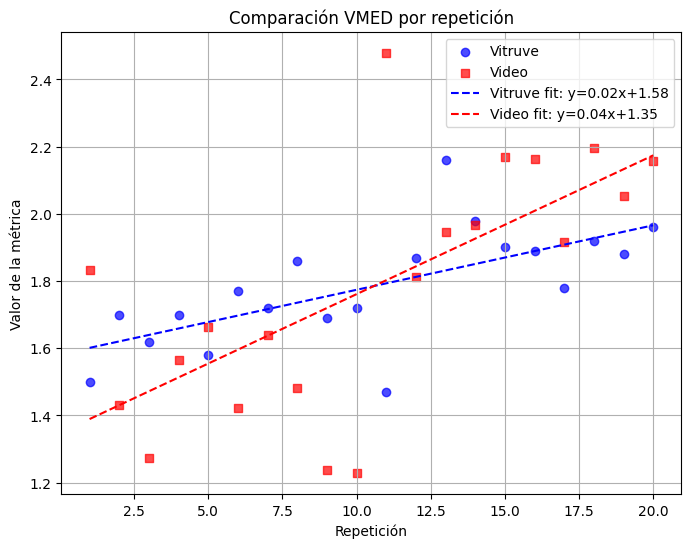

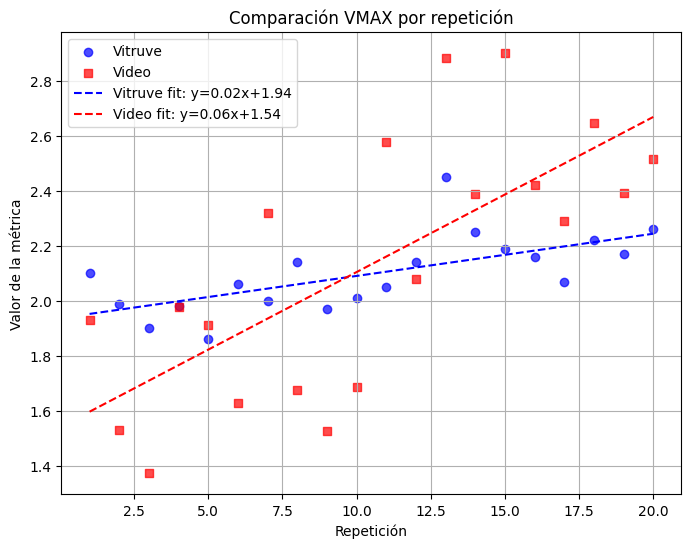

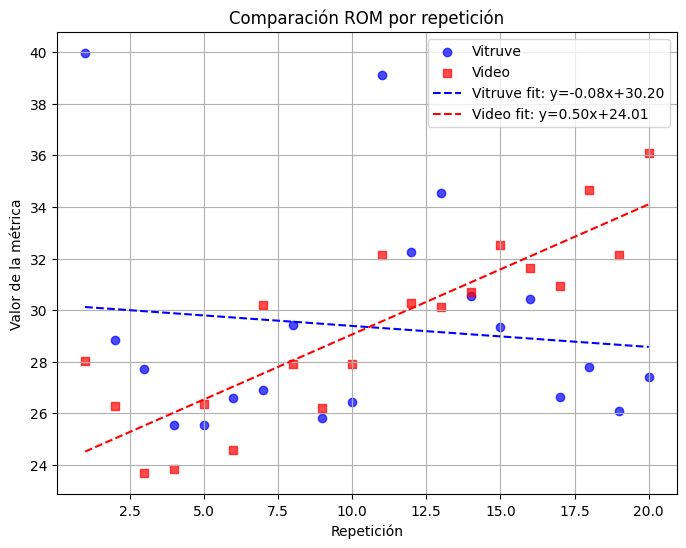

In [ ]:
plot_comparison_by_rep(benchdips_merge_df, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(benchdips_merge_df, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(benchdips_merge_df, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")

In [ ]:
df_vmed = benchdips_merge_df[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = benchdips_merge_df[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = benchdips_merge_df[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

Ratio VMED (Vitruve/Video) = 1.4441574869551466
Ratio VMAX (Vitruve/Video) = 1.150280803843291
Ratio ROM (Vitruve/Video) = 1.4141789657608088


# Zancada trasera

## Vista frontal

the reps count measured in video is: 38
the reps count measured in vitruve is: 39
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.1692
 MAE: 0.3184
 MRE: 39.12%

 R²: -7.9405

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 3.1193
 MAE: 1.7100
 MRE: 123.88%

 R²: -157.6921

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 93.6074
 MAE: 6.7357
 MRE: 19.99%

 R²: -2.3400



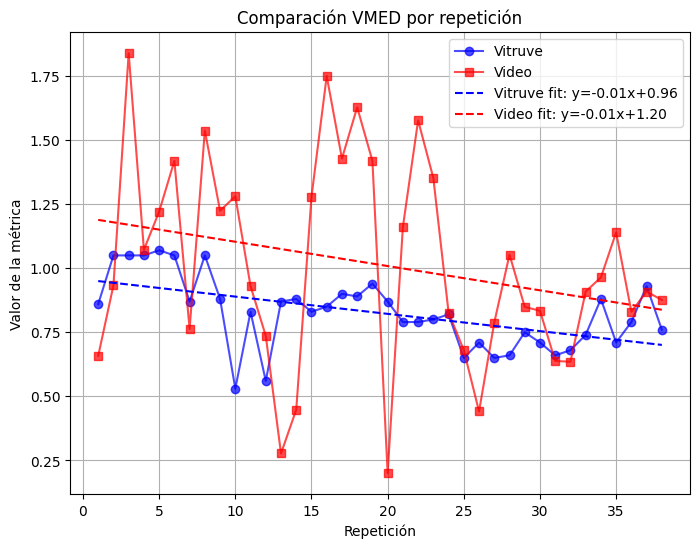

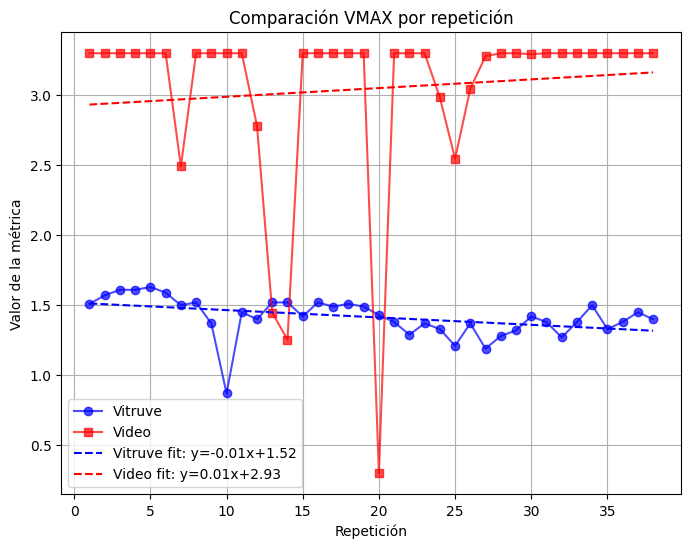

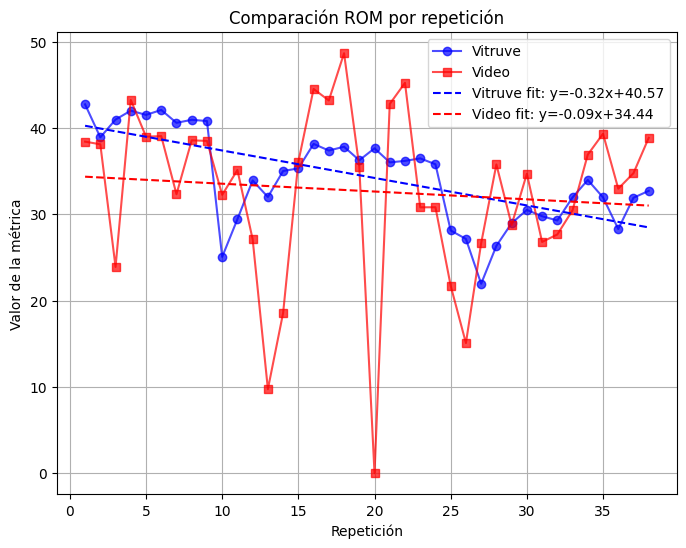

Ratio VMED (Vitruve/Video) = 0.8144608352378974
Ratio VMAX (Vitruve/Video) = 0.4643372100050942
Ratio ROM (Vitruve/Video) = 1.0515668650699381


In [ ]:
df_vitruve = pd.read_csv(vitruve_path_3, skiprows=1)
df_zt_front1 = pd.read_csv('../data_export/rear_lunge/20250404_125945_rear_lunge_metrics.csv')
df_zt_front2 = pd.read_csv('../data_export/rear_lunge/20250404_130129_rear_lunge_metrics.csv')
df_zt_front3 = pd.read_csv('../data_export/rear_lunge/20250404_130458_rear_lunge_metrics.csv')
df_video_zt_front = pd.concat([df_zt_front1, df_zt_front2, df_zt_front3], ignore_index=True)
df_video_zt_front['repetition_index'] = range(1, len(df_video_zt_front) + 1)
print(f"the reps count measured in video is: {df_video_zt_front.shape[0]}")

df_vitruve_zt_front =  df_vitruve[df_vitruve['Nº Serie'].isin([13,14,15])][df_vitruve['Tipo*']=='C']
df_vitruve_zt_front['repetition_index'] = range(1, len(df_vitruve_zt_front) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_zt_front.shape[0]}")


df_vitruve_zt_front.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_zt_front.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_zt_front = pd.merge(df_vitruve_zt_front, df_video_zt_front, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_zt_front[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_zt_front[video_col].astype(str).str.replace(',', '.').astype(float)

    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_zt_front, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_zt_front, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_zt_front, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_zt_front[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_zt_front[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_zt_front[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)


## Vista lateral

the reps count measured in video is: 14
the reps count measured in vitruve is: 28
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.0794
 MAE: 0.2610
 MRE: 48.11%

 R²: -0.4471

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.1925
 MAE: 0.3601
 MRE: 34.92%

 R²: -2.1963

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 48.2448
 MAE: 4.8895
 MRE: 11.59%

 R²: -2.8475



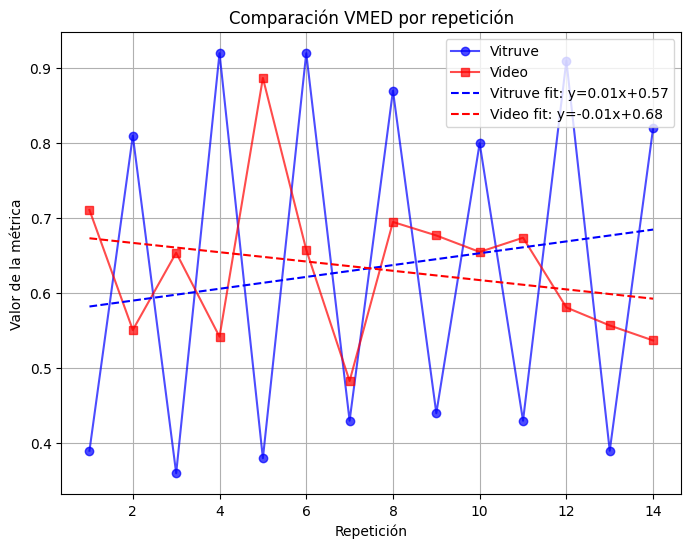

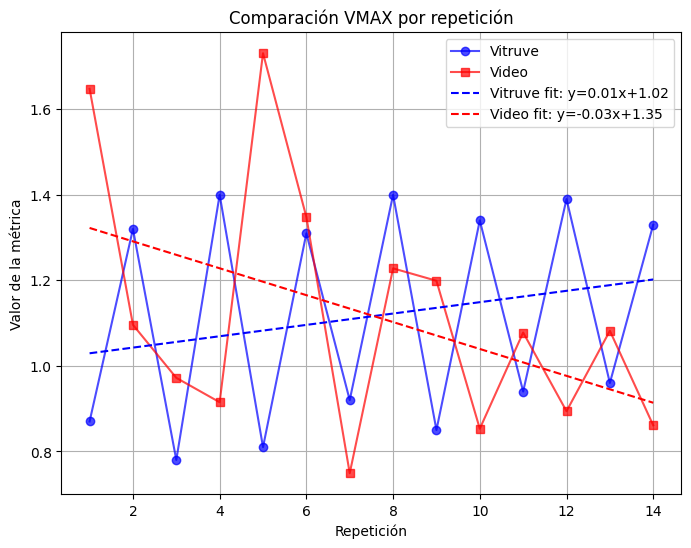

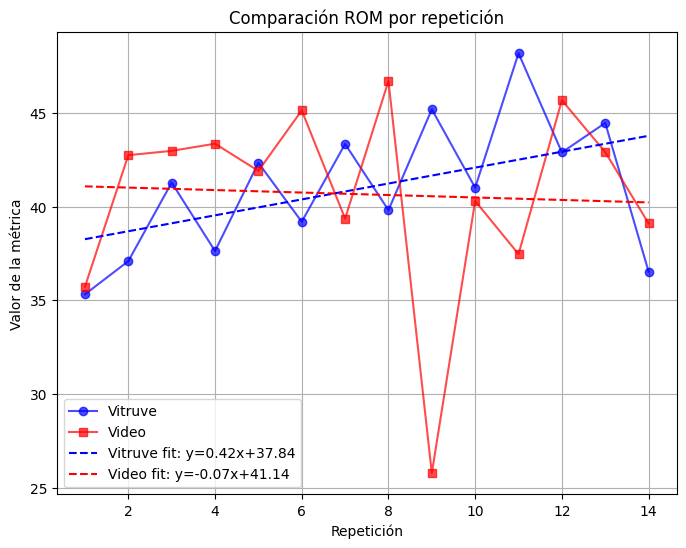

Ratio VMED (Vitruve/Video) = 1.0009027307605507
Ratio VMAX (Vitruve/Video) = 0.9978280311741405
Ratio ROM (Vitruve/Video) = 1.0090476031495288


In [18]:
df_vitruve = pd.read_csv('../data/TEST_03-04-2025.csv', skiprows=1, index_col=False)
df_zt_lat1 = pd.read_csv('../data_export/rear_lunge/20250408_102930_rear_lunge_metrics.csv')
df_zt_lat2 = pd.read_csv('../data_export/rear_lunge/20250408_103006_rear_lunge_metrics.csv')
df_video_zt_lat = pd.concat([df_zt_lat1, df_zt_lat2], ignore_index=True)
df_video_zt_lat['repetition_index'] = range(1, len(df_video_zt_lat) + 1)
print(f"the reps count measured in video is: {df_video_zt_lat.shape[0]}")

df_vitruve_zt_lat = df_vitruve[df_vitruve['Nº Serie'].isin([12, 13])]
df_vitruve_zt_lat = df_vitruve_zt_lat[df_vitruve_zt_lat['Nº Repetición'] % 2 != 0]  # Filtramos repeticiones impares
df_vitruve_zt_lat['repetition_index'] = range(1, len(df_vitruve_zt_lat) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_zt_lat.shape[0]}")

df_vitruve_zt_lat.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_zt_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_zt_lat = pd.merge(df_vitruve_zt_lat, df_video_zt_lat, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_zt_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_zt_lat[video_col].astype(str).str.replace(',', '.').astype(float)

    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_zt_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_zt_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_zt_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_zt_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_zt_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_zt_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)


In [ ]:
def plot_scatter_ordered(df, vitruve_col, video_col, title):
    # Ordenar el DataFrame por las mediciones de Vitruve (eje X)
    df_sorted = df.sort_values(by=vitruve_col)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(df_sorted[vitruve_col], df_sorted[video_col], alpha=0.6)
    plt.xlabel(f'{vitruve_col} (Vitruve)', fontsize=12)
    plt.ylabel(f'{video_col} (Video)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True)
    plt.show()


# Gráfico para VMED
plot_scatter_ordered(df_zt_lat, 'Vitruve_VMED', 'Video_VMED', "Dispersión entre VMED de Vitruve y Video")

# Gráfico para VMAX
plot_scatter_ordered(df_zt_lat, 'Vitruve_VMAX', 'Video_VMAX', "Dispersión entre VMAX de Vitruve y Video")

# Gráfico para ROM
plot_scatter_ordered(df_zt_lat, 'Vitruve_ROM', 'Video_ROM', "Dispersión entre ROM de Vitruve y Video")


# Renegade row 

## Vista frontal

the reps count measured in video is: 25
the reps count measured in vitruve is: 25
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.5517
 MAE: 0.7308
 MRE: 39.81%

 R²: -44.1755

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.4976
 MAE: 0.6520
 MRE: 26.26%

 R²: -14.9439

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 182.3751
 MAE: 10.2477
 MRE: 23.99%

 R²: -2.7985



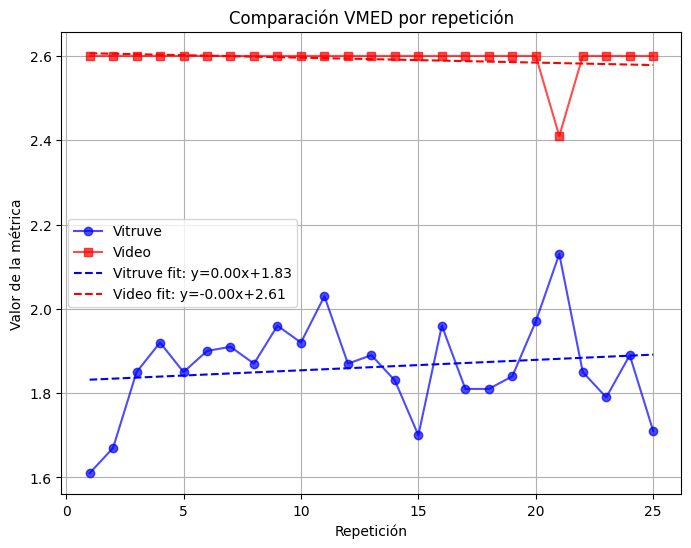

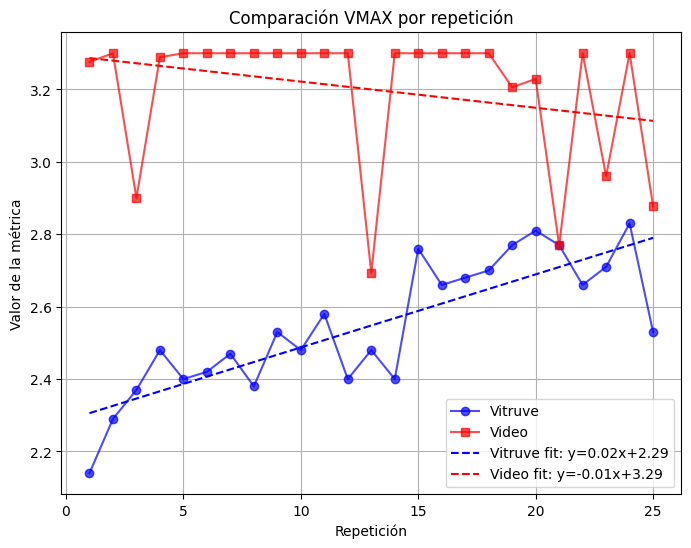

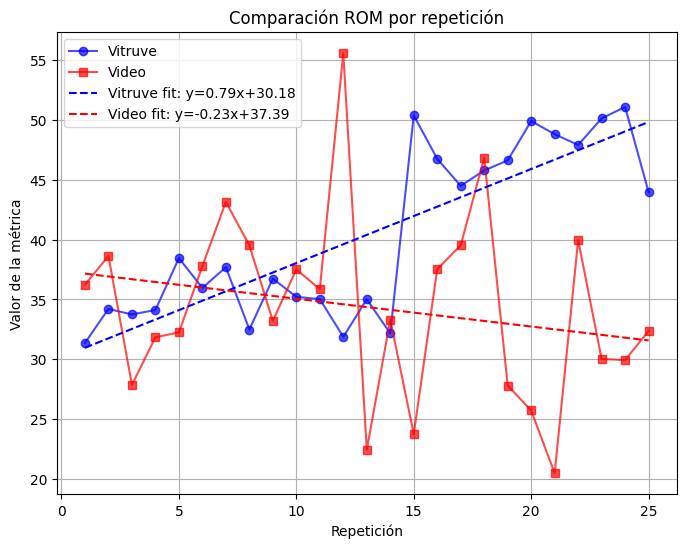

Ratio VMED (Vitruve/Video) = 0.7180990587872241
Ratio VMAX (Vitruve/Video) = 0.7962599532494157
Ratio ROM (Vitruve/Video) = 1.175590146113683


In [ ]:
df_vitruve = pd.read_csv(vitruve_path_3, skiprows=1)
df_rr_front1 = pd.read_csv('../data_export/renegade_row/20250406_120447_renegade_row_metrics.csv')
df_rr_front2 = pd.read_csv('../data_export/renegade_row/20250406_120543_renegade_row_metrics.csv')
df_video_rr_front = pd.concat([df_rr_front1, df_rr_front2], ignore_index=True)
df_video_rr_front['repetition_index'] = range(1, len(df_video_rr_front) + 1)
print(f"the reps count measured in video is: {df_video_rr_front.shape[0]}")

df_vitruve_rr_front =  df_vitruve[df_vitruve['Nº Serie'].isin([16,17])][df_vitruve['Tipo*']=='C']
df_vitruve_rr_front['repetition_index'] = range(1, len(df_vitruve_rr_front) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_rr_front.shape[0]}")


df_vitruve_rr_front.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_rr_front.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_rr_front = pd.merge(df_vitruve_rr_front, df_video_rr_front, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_rr_front[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_rr_front[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_rr_front, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_rr_front, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_rr_front, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_rr_front[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_rr_front[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_rr_front[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)


In [ ]:
df_vitruve = pd.read_csv('../data/TEST_28-03-2025.csv', skiprows = 1)
df_renegaderow_vitrube = df_vitruve[df_vitruve['Tipo*']=='C'][(df_vitruve['Nº Serie']==18) | (df_vitruve['Nº Serie']==19)][vitruve_columns].reset_index()
df_renegaderow_vitrube['repetition_index'] = range(1, len(df_renegaderow_vitrube) + 1)
df_renegaderow_vitrube.shape[0]

25

In [ ]:
df_renegaderow_video = pd.read_csv('../data_export/renegade_row_metrics.csv')
df_renegaderow_video['repetition_index'] = range(1, len(df_renegaderow_video) + 1)
df_renegaderow_video = df_renegaderow_video[df_renegaderow_video['repetition_index']!=26]
df_renegaderow_video.shape[0]

25

In [ ]:
df_renegaderow_vitrube.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_renegaderow_video.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

In [ ]:
renegaderow_merge_df = pd.merge(df_renegaderow_vitrube, df_renegaderow_video, how = 'inner', on = 'repetition_index')
renegaderow_merge_df.head()

,index,Fecha repetición,Nº Serie,Nº Repetición,Tipo*,Vitruve_VMED,Vitruve_VMAX,Vitruve_ROM,repetition_index,start_datetime,...,gender,height (m),effective_length (m),min_angle (°),max_angle (°),Video_ROM,Video_VMED,Video_VMAX,rep_time,repetition
0,394,10:35:13,18,1,C,"2,3","2,83","42,34",1,2025-04-02T08:57:20.638390,...,male,1.84,0.706,77.789,131.097,26.519,1.620,1.720,0.40,1
1,396,10:35:15,18,2,C,"1,77","2,32","34,73",2,2025-04-02T08:57:37.287077,...,male,1.84,0.706,78.450,135.356,28.769,1.794,1.894,0.40,2
2,398,10:35:16,18,3,C,"1,87","2,38","31,64",3,2025-04-02T08:57:50.434814,...,male,1.84,0.706,66.625,138.801,36.778,2.552,2.652,0.40,3
3,400,10:35:19,18,4,C,"1,87","2,42","32,53",4,2025-04-02T08:58:14.215158,...,male,1.84,0.706,71.698,126.681,27.569,2.175,2.275,0.40,4
4,402,10:35:21,18,5,C,"1,51","1,96","31,66",5,2025-04-02T08:58:37.240664,...,male,1.84,0.706,71.810,137.908,32.647,1.658,1.758,0.52,5


In [ ]:
for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = renegaderow_merge_df[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = renegaderow_merge_df[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    
    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")

*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.1727
 MAE: 0.3122
 MRE: 20.99%

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.2358
 MAE: 0.3988
 MRE: 19.84%

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 34.4688
 MAE: 4.6484
 MRE: 13.98%



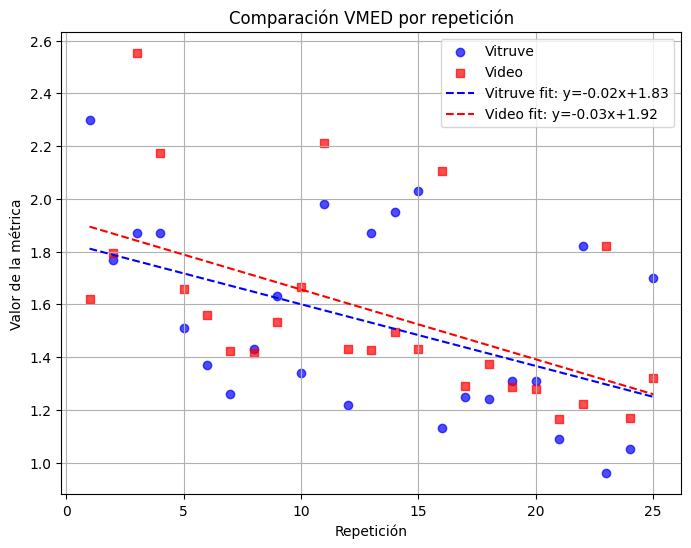

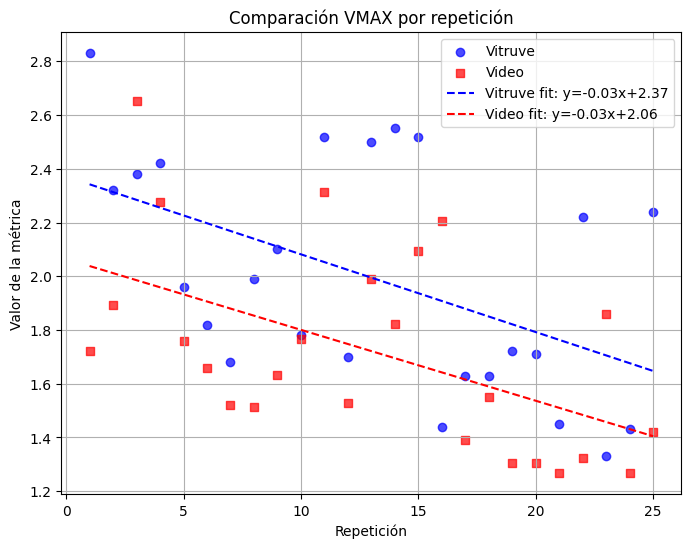

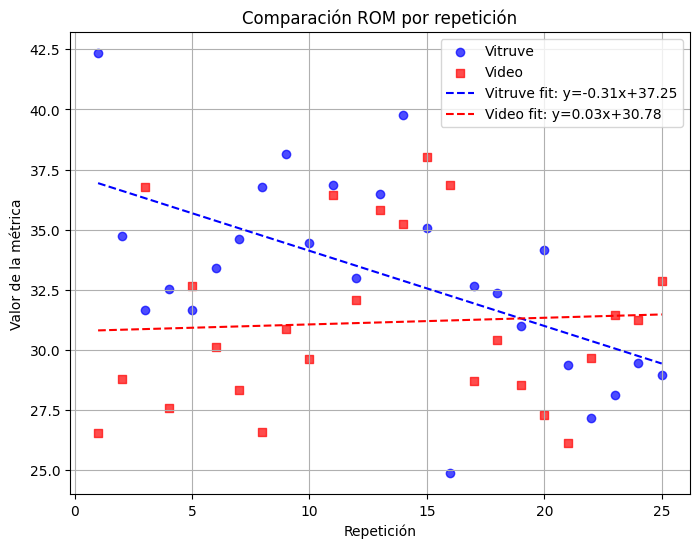

In [ ]:
plot_comparison_by_rep(renegaderow_merge_df, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(renegaderow_merge_df, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(renegaderow_merge_df, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")

In [ ]:
df_vmed = renegaderow_merge_df[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = renegaderow_merge_df[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = renegaderow_merge_df[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

Ratio VMED (Vitruve/Video) = 0.9704256074671539
Ratio VMAX (Vitruve/Video) = 1.158824212850006
Ratio ROM (Vitruve/Video) = 1.0656116793722494


## Vista lateral

the reps count measured in video is: 26
the reps count measured in vitruve is: 25
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.1536
 MAE: 0.2891
 MRE: 18.60%

 R²: -0.2160

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.3243
 MAE: 0.4725
 MRE: 23.63%

 R²: -0.8335

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 40.2758
 MAE: 5.1064
 MRE: 14.93%

 R²: -1.5966



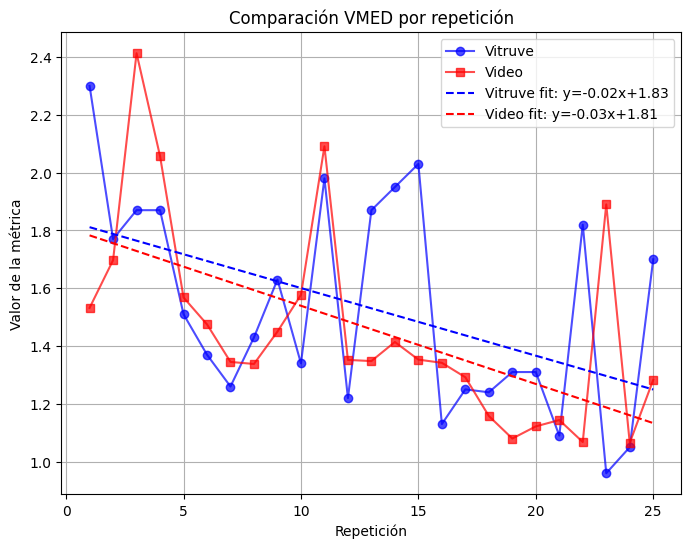

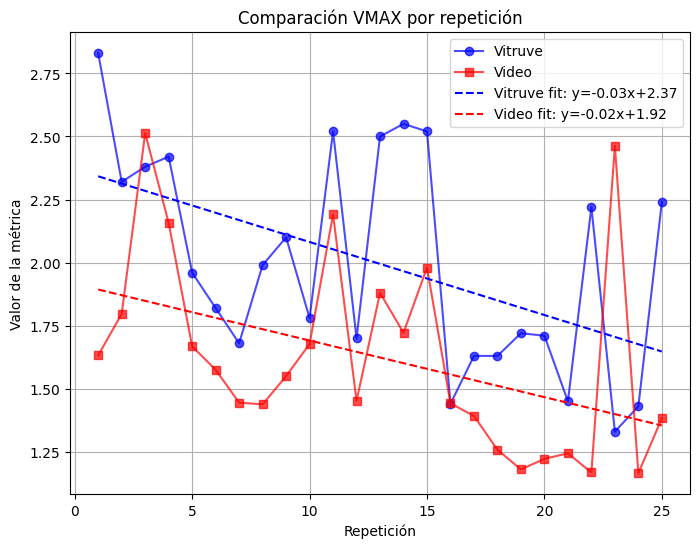

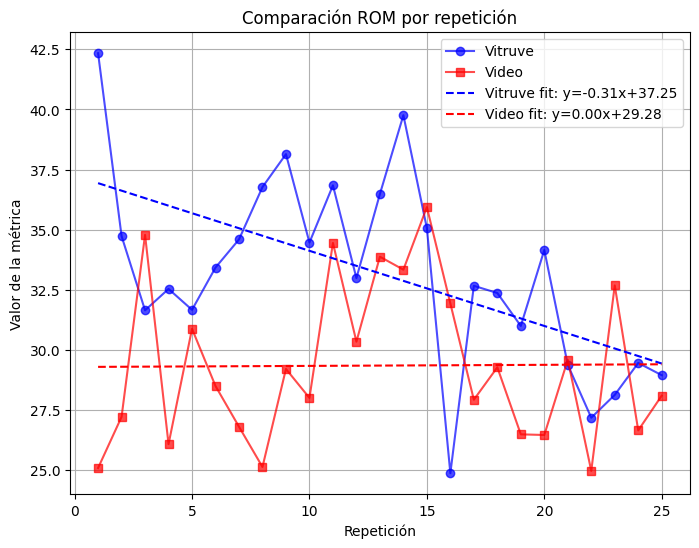

Ratio VMED (Vitruve/Video) = 1.049541888407308
Ratio VMAX (Vitruve/Video) = 1.228506675863428
Ratio ROM (Vitruve/Video) = 1.1308369041078337


In [ ]:
df_vitruve = pd.read_csv(vitruve_path_3, skiprows=1)
df_rr_lat1 = pd.read_csv('../data_export/renegade_row/20250406_120635_renegade_row_metrics.csv')
df_rr_lat2 = pd.read_csv('../data_export/renegade_row/20250406_120712_renegade_row_metrics.csv')
df_video_rr_lat = pd.concat([df_rr_lat1, df_rr_lat2], ignore_index=True)
df_video_rr_lat['repetition_index'] = range(1, len(df_video_rr_lat) + 1)
print(f"the reps count measured in video is: {df_video_rr_lat.shape[0]}")

df_vitruve_rr_lat =  df_vitruve[df_vitruve['Nº Serie'].isin([18,19])][df_vitruve['Tipo*']=='C']
df_vitruve_rr_lat['repetition_index'] = range(1, len(df_vitruve_rr_lat) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_rr_lat.shape[0]}")


df_vitruve_rr_lat.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_rr_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_rr_lat = pd.merge(df_vitruve_rr_lat, df_video_rr_lat, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_rr_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_rr_lat[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_rr_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_rr_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_rr_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_rr_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_rr_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_rr_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)


In [ ]:
df_vitruve = pd.read_csv('../data/TEST_28-03-2025.csv', skiprows = 1)
df_renegaderow_vitrube = df_vitruve[df_vitruve['Tipo*']=='C'][(df_vitruve['Nº Serie']==16) | (df_vitruve['Nº Serie']==17)][vitruve_columns].reset_index()
df_renegaderow_vitrube['repetition_index'] = range(1, len(df_renegaderow_vitrube) + 1)
df_renegaderow_vitrube.shape[0]

25

In [ ]:
df_renegaderow_video = pd.read_csv('../data_export/renegade_row_metrics.csv')
df_renegaderow_video['repetition_index'] = range(1, len(df_renegaderow_video) + 1)
df_renegaderow_video = df_renegaderow_video[df_renegaderow_video['repetition_index']!=26]
df_renegaderow_video.shape[0]

25

In [ ]:
df_renegaderow_vitrube.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_renegaderow_video.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

In [ ]:
renegaderow_merge_df = pd.merge(df_renegaderow_vitrube, df_renegaderow_video, how = 'inner', on = 'repetition_index')
renegaderow_merge_df.head()

,index,Fecha repetición,Nº Serie,Nº Repetición,Tipo*,Vitruve_VMED,Vitruve_VMAX,Vitruve_ROM,repetition_index,start_datetime,...,gender,height (m),effective_length (m),min_angle (°),max_angle (°),Video_ROM,Video_VMED,Video_VMAX,rep_time,repetition
0,346,10:25:57,16,1,C,"1,61","2,14","31,37",1,2025-04-02T09:13:18.986446,...,male,1.84,0.706,61.034,131.708,38.328,2.6,2.9,0.24,1
1,348,10:25:59,16,2,C,"1,67","2,29","34,21",2,2025-04-02T09:13:33.073034,...,male,1.84,0.706,50.563,133.728,40.850,2.6,2.9,0.28,2
2,350,10:26:01,16,3,C,"1,85","2,37","33,75",3,2025-04-02T09:13:53.917111,...,male,1.84,0.706,54.199,111.440,29.459,2.6,2.9,0.20,3
3,352,10:26:03,16,4,C,"1,92","2,48","34,12",4,2025-04-02T09:14:11.227325,...,male,1.84,0.706,55.294,124.052,33.675,2.6,2.9,0.24,4
4,354,10:26:06,16,5,C,"1,85","2,4","38,46",5,2025-04-02T09:14:38.782073,...,male,1.84,0.706,54.719,124.476,34.095,2.6,2.9,0.24,5


In [ ]:
for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = renegaderow_merge_df[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = renegaderow_merge_df[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    
    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")

*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.5556
 MAE: 0.7363
 MRE: 40.07%

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.1535
 MAE: 0.3499
 MRE: 14.29%

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 171.6827
 MAE: 10.1323
 MRE: 24.22%



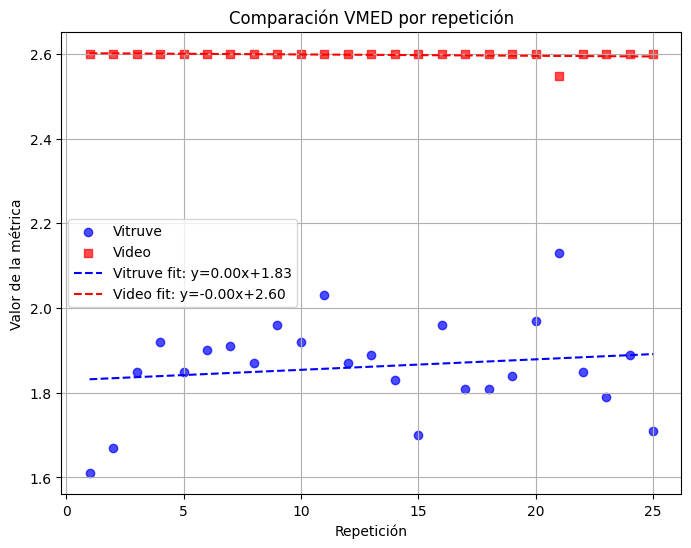

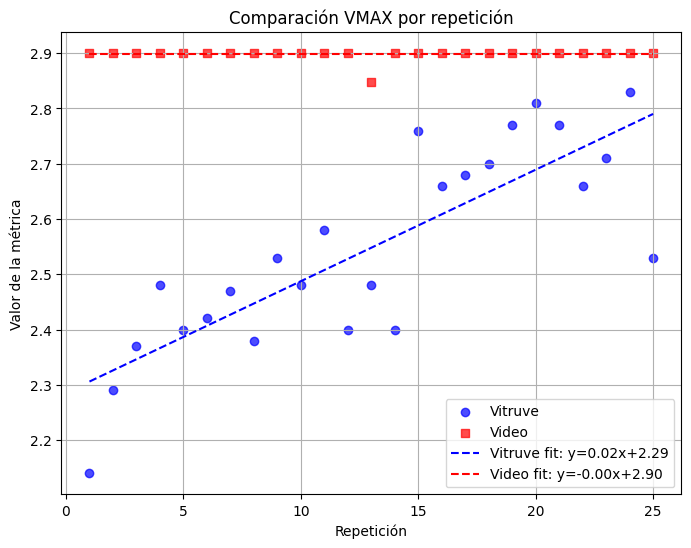

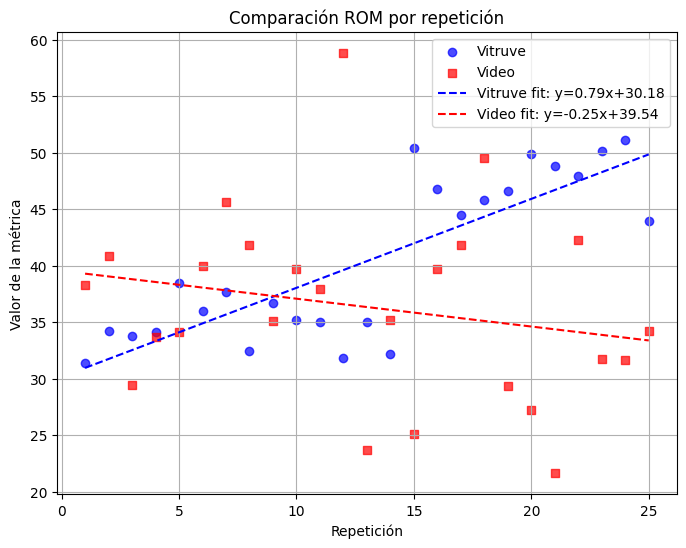

In [ ]:
plot_comparison_by_rep(renegaderow_merge_df, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(renegaderow_merge_df, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(renegaderow_merge_df, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")

In [ ]:
df_vmed = renegaderow_merge_df[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = renegaderow_merge_df[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = renegaderow_merge_df[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

Ratio VMED (Vitruve/Video) = 0.7165732586068854
Ratio VMAX (Vitruve/Video) = 0.8792513250883391
Ratio ROM (Vitruve/Video) = 1.1116724173036392


# Swing

## Vista lateral

the reps count measured in video is: 27
the reps count measured in vitruve is: 29
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.3235
 MAE: 0.3353
 MRE: 27.55%

 R²: -0.9989

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.6968
 MAE: 0.4980
 MRE: 24.52%

 R²: -1.8484

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 857.3740
 MAE: 14.0758
 MRE: 30.13%

 R²: -1.3566



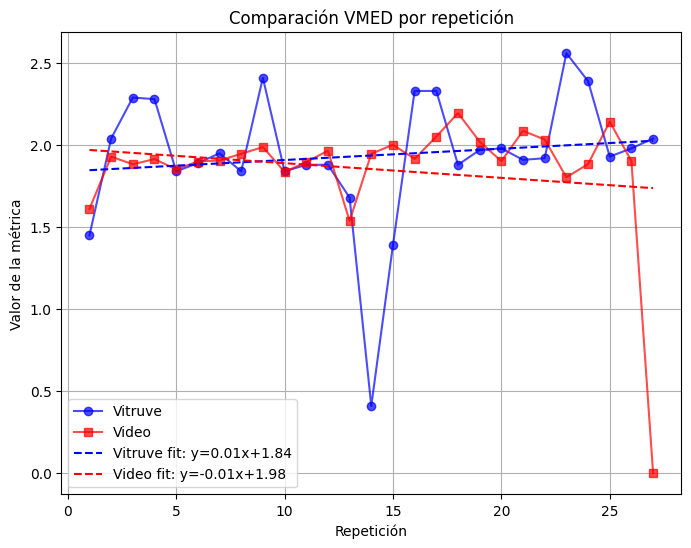

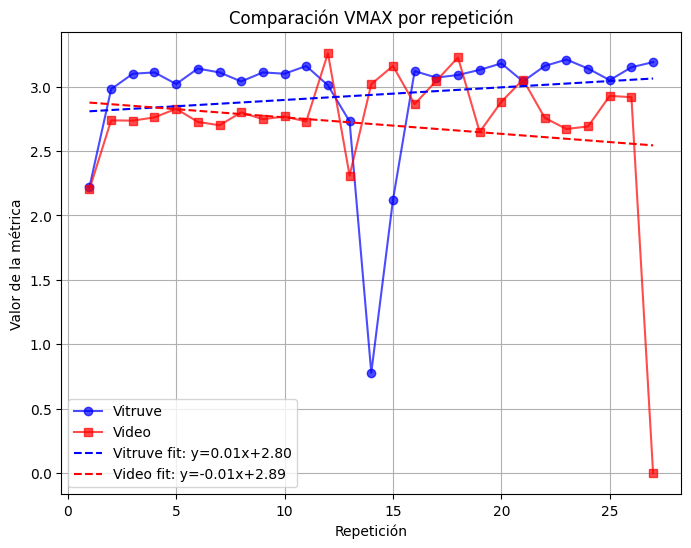

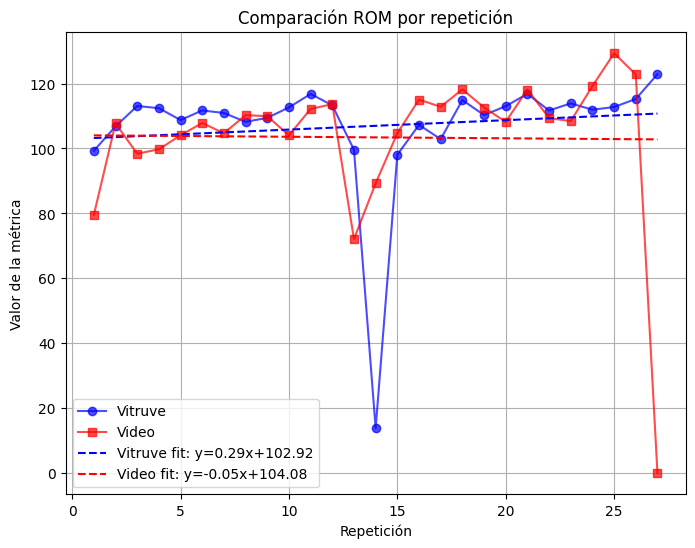

Ratio VMED (Vitruve/Video) = 1.0445674104556624
Ratio VMAX (Vitruve/Video) = 1.0832160282078966
Ratio ROM (Vitruve/Video) = 1.0344206402074336


In [ ]:
df_vitruve = pd.read_csv(vitruve_path_3, skiprows=1)
df_swing_lat1 = pd.read_csv('../data_export/swing/20250406_122607_swing_metrics.csv')
df_swing_lat2 = pd.read_csv('../data_export/swing/20250406_122637_swing_metrics.csv')
df_video_swing_lat = pd.concat([df_swing_lat1, df_swing_lat2], ignore_index=True)
df_video_swing_lat['repetition_index'] = range(1, len(df_video_swing_lat) + 1)
print(f"the reps count measured in video is: {df_video_swing_lat.shape[0]}")

df_vitruve_swing_lat =  df_vitruve[df_vitruve['Nº Serie'].isin([22,23])][df_vitruve['Tipo*']=='C']
df_vitruve_swing_lat['repetition_index'] = range(1, len(df_vitruve_swing_lat) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_swing_lat.shape[0]}")


df_vitruve_swing_lat.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_swing_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_swing_lat = pd.merge(df_vitruve_swing_lat, df_video_swing_lat, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_swing_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_swing_lat[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_swing_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_swing_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_swing_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_swing_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_swing_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_swing_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)


In [ ]:
df_vitruve = pd.read_csv('../data/TEST_28-03-2025.csv', skiprows = 1)
df_swing_vitruve = df_vitruve[df_vitruve['Tipo*']=='C'][(df_vitruve['Nº Serie']==22) | (df_vitruve['Nº Serie']==23)][vitruve_columns].reset_index()
df_swing_vitruve['repetition_index'] = range(1, len(df_swing_vitruve) + 1)
df_swing_vitruve = df_swing_vitruve[(df_swing_vitruve['repetition_index']!=14)& (df_swing_vitruve['repetition_index']!=15)]
df_swing_vitruve['repetition_index'] = range(1, len(df_swing_vitruve) + 1)
df_swing_vitruve.shape[0]

27

In [ ]:
df_swing_video = pd.read_csv('../data_export/swing_metrics.csv')
df_swing_video['repetition_index'] = range(1, len(df_swing_video) + 1)
df_swing_video.shape[0]

27

In [ ]:
df_swing_vitruve.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_swing_video.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

In [ ]:
swing_merge_df = pd.merge(df_swing_vitruve, df_swing_video, how = 'inner', on = 'repetition_index')
swing_merge_df.head()

,index,Fecha repetición,Nº Serie,Nº Repetición,Tipo*,Vitruve_VMED,Vitruve_VMAX,Vitruve_ROM,repetition_index,start_datetime,...,gender,height (m),effective_length (m),min_angle (°),max_angle (°),Video_ROM,Video_VMED,Video_VMAX,rep_time,repetition
0,492,10:49:42,22,1,C,"1,45","2,22","99,29",1,2025-04-02T11:18:42.340737,...,male,1.84,0.706,38.285,88.273,84.099,1.703,2.331,0.68,1
1,494,10:49:43,22,2,C,"2,04","2,98","106,79",2,2025-04-02T11:18:54.387543,...,male,1.84,0.706,35.884,103.131,113.906,2.042,2.896,0.72,2
2,496,10:49:44,22,3,C,"2,29","3,1","113,07",3,2025-04-02T11:19:07.383488,...,male,1.84,0.706,44.225,105.908,104.056,1.992,2.893,0.76,3
3,498,10:49:46,22,4,C,"2,28","3,11","112,41",4,2025-04-02T11:19:20.049558,...,male,1.84,0.706,44.926,107.975,105.465,2.025,2.920,0.76,4
4,500,10:49:47,22,5,C,"1,84","3,02","108,75",5,2025-04-02T11:19:32.485931,...,male,1.84,0.706,39.773,105.194,110.048,1.958,2.990,0.76,5


In [ ]:
for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = swing_merge_df[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = swing_merge_df[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    
    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")

*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.0446
 MAE: 0.1801
 MRE: 11.79%

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.0553
 MAE: 0.1903
 MRE: 9.03%

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 88.5086
 MAE: 7.7216
 MRE: 10.20%



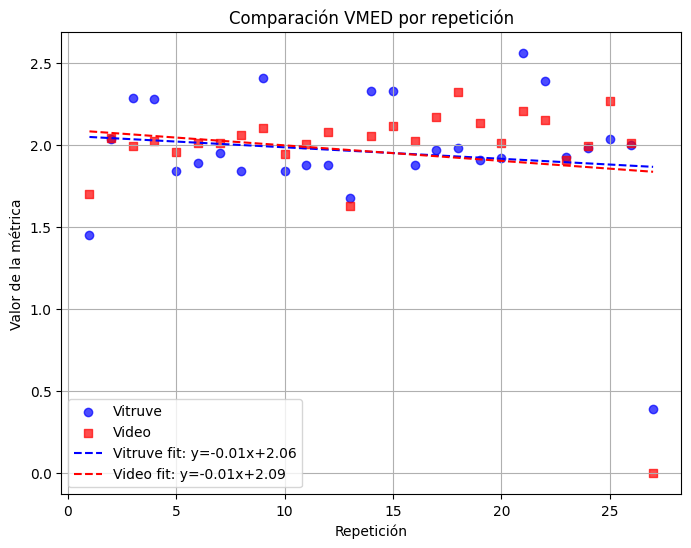

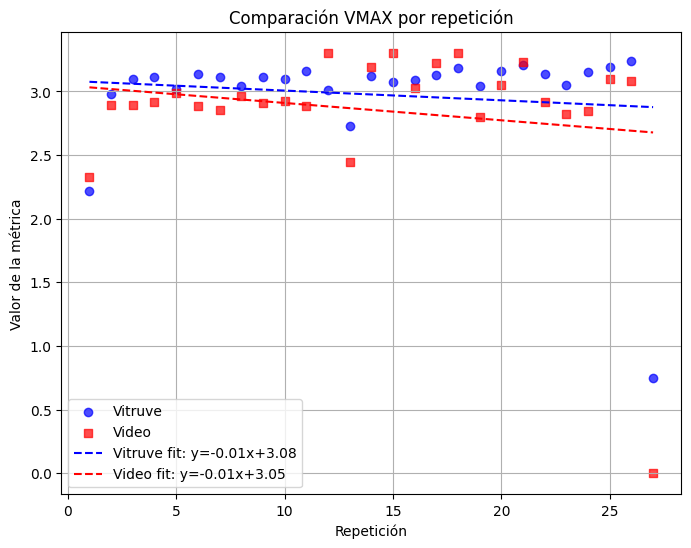

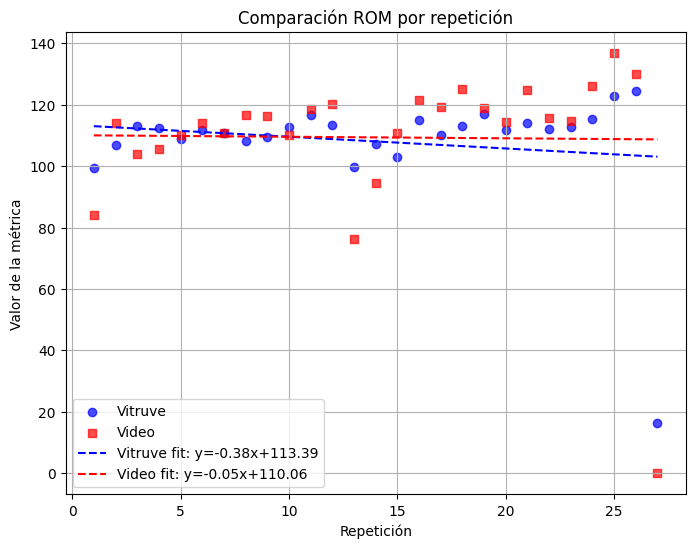

In [ ]:
plot_comparison_by_rep(swing_merge_df, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(swing_merge_df, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(swing_merge_df, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")

In [ ]:
df_vmed = swing_merge_df[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = swing_merge_df[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = swing_merge_df[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

Ratio VMED (Vitruve/Video) = 0.9989609898932654
Ratio VMAX (Vitruve/Video) = 1.042450504683567
Ratio ROM (Vitruve/Video) = 0.9879387175497858


## Vista frontal

the reps count measured in video is: 23
the reps count measured in vitruve is: 25
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.6272
 MAE: 0.5674
 MRE: 27.46%

 R²: -2.9228

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.6048
 MAE: 0.3074
 MRE: 9.89%

 R²: -7.5289

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 8398.0805
 MAE: 89.6193
 MRE: 78.27%

 R²: -220.7522



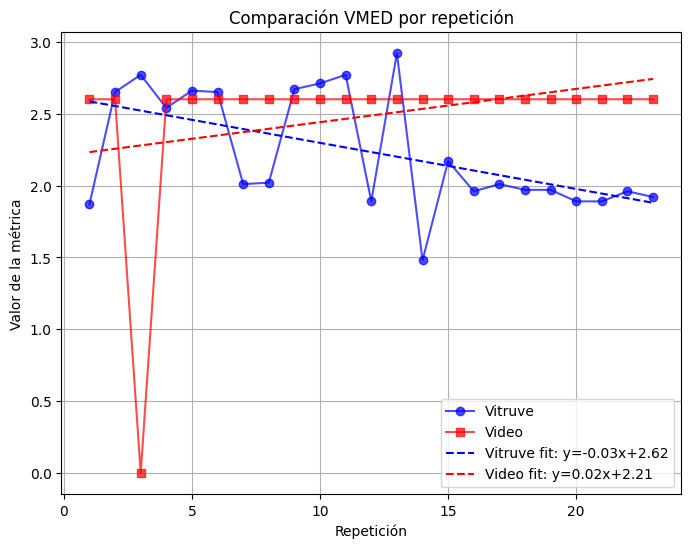

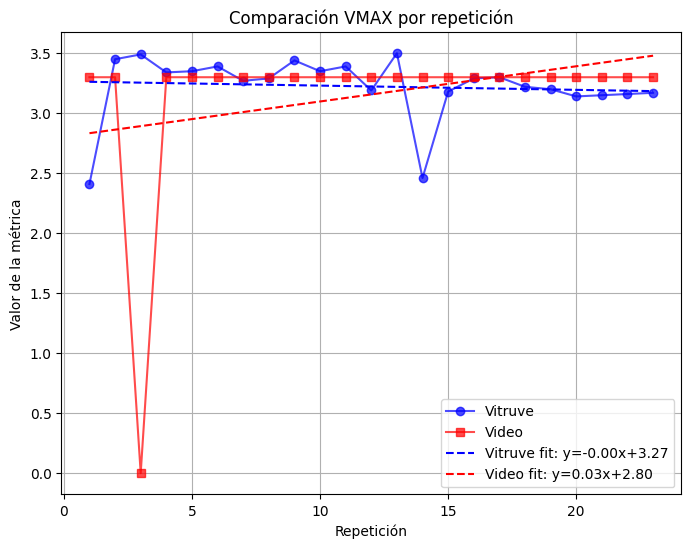

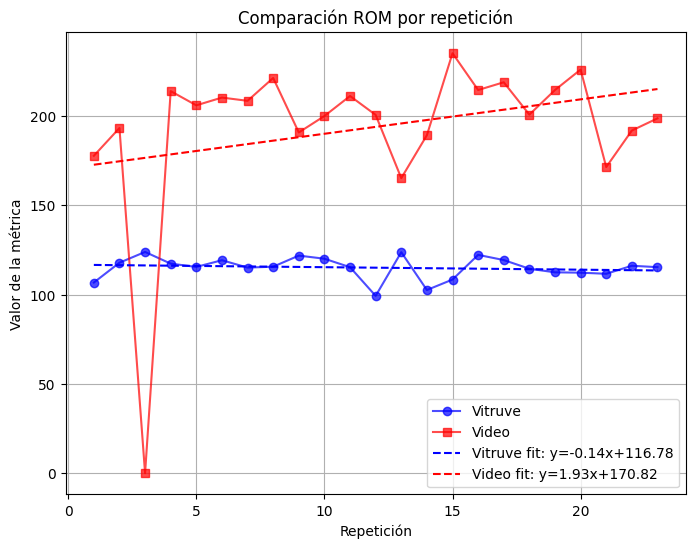

Ratio VMED (Vitruve/Video) = 0.8977272727272725
Ratio VMAX (Vitruve/Video) = 1.0210743801652897
Ratio ROM (Vitruve/Video) = 0.5934606142222414


In [ ]:
df_vitruve = pd.read_csv(vitruve_path_3, skiprows=1)
df_swing_front1 = pd.read_csv('../data_export/swing/20250406_122600_swing_metrics.csv')
df_swing_front2 = pd.read_csv('../data_export/swing/20250406_122613_swing_metrics.csv')
df_video_swing_front = pd.concat([df_swing_front1, df_swing_front2], ignore_index=True)
df_video_swing_front['repetition_index'] = range(1, len(df_video_swing_front) + 1)
print(f"the reps count measured in video is: {df_video_swing_front.shape[0]}")

df_vitruve_swing_front =  df_vitruve[df_vitruve['Nº Serie'].isin([20,21])][df_vitruve['Tipo*']=='C']
df_vitruve_swing_front['repetition_index'] = range(1, len(df_vitruve_swing_front) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_swing_front.shape[0]}")


df_vitruve_swing_front.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_swing_front.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_swing_front = pd.merge(df_vitruve_swing_front, df_video_swing_front, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_swing_front[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_swing_front[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_swing_front, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_swing_front, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_swing_front, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_swing_front[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_swing_front[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_swing_front[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)


In [ ]:
df_vitruve = pd.read_csv('../data/TEST_28-03-2025.csv', skiprows = 1)
df_swing_vitruve = df_vitruve[df_vitruve['Tipo*']=='C'][(df_vitruve['Nº Serie']==20) | (df_vitruve['Nº Serie']==21)][vitruve_columns].reset_index()
df_swing_vitruve['repetition_index'] = range(1, len(df_swing_vitruve) + 1)
df_swing_vitruve = df_swing_vitruve[(df_swing_vitruve['repetition_index']!=14)& (df_swing_vitruve['repetition_index']!=15)]
df_swing_vitruve['repetition_index'] = range(1, len(df_swing_vitruve) + 1)
df_swing_vitruve.shape[0]

23

In [ ]:
df_swing_video = pd.read_csv('../data_export/swing_metrics.csv')
df_swing_video['repetition_index'] = range(1, len(df_swing_video) + 1)
df_swing_video.shape[0]

23

In [ ]:
df_swing_vitruve.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_swing_video.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

In [ ]:
swing_merge_df = pd.merge(df_swing_vitruve, df_swing_video, how = 'inner', on = 'repetition_index')
swing_merge_df.head()

,index,Fecha repetición,Nº Serie,Nº Repetición,Tipo*,Vitruve_VMED,Vitruve_VMAX,Vitruve_ROM,repetition_index,start_datetime,...,gender,height (m),effective_length (m),min_angle (°),max_angle (°),Video_ROM,Video_VMED,Video_VMAX,rep_time,repetition
0,443,10:43:50,20,1,C,"1,87","2,41","106,78",1,2025-04-02T11:27:33.543647,...,male,1.84,0.706,49.544,163.346,174.743,2.6,3.3,0.40,1
1,445,10:43:51,20,2,C,"2,65","3,45","117,88",2,2025-04-02T11:27:48.579882,...,male,1.84,0.706,58.521,167.222,200.165,2.6,3.3,0.64,2
2,447,10:43:53,20,3,C,"2,77","3,49","123,91",3,2025-04-02T11:28:04.244340,...,male,1.84,0.706,37.518,174.121,248.713,2.6,3.3,0.80,3
3,449,10:43:54,20,4,C,"2,54","3,34","117,36",4,2025-04-02T11:28:18.551291,...,male,1.84,0.706,46.649,169.237,226.922,2.6,3.3,0.68,4
4,451,10:43:55,20,5,C,"2,66","3,35","115,53",5,2025-04-02T11:28:32.300570,...,male,1.84,0.706,41.497,173.038,231.516,2.6,3.3,0.68,5


In [ ]:
for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = swing_merge_df[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = swing_merge_df[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    
    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")

*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.4188
 MAE: 0.5013
 MRE: 25.08%

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.5170
 MAE: 0.2735
 MRE: 8.74%

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 10244.1611
 MAE: 99.6901
 MRE: 86.05%



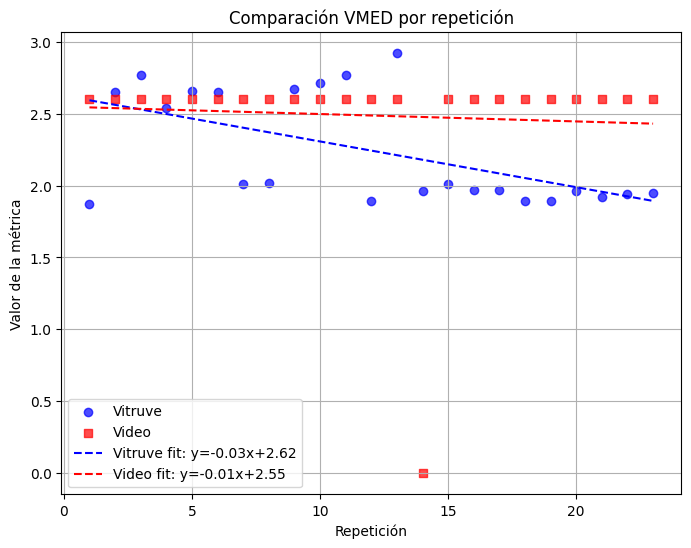

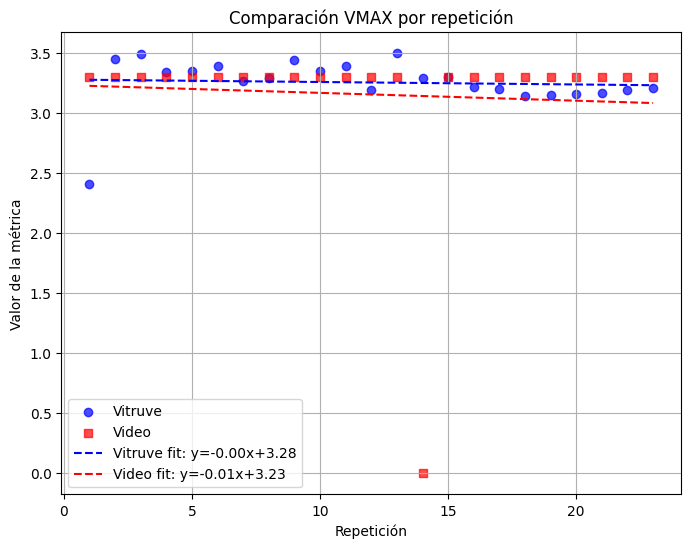

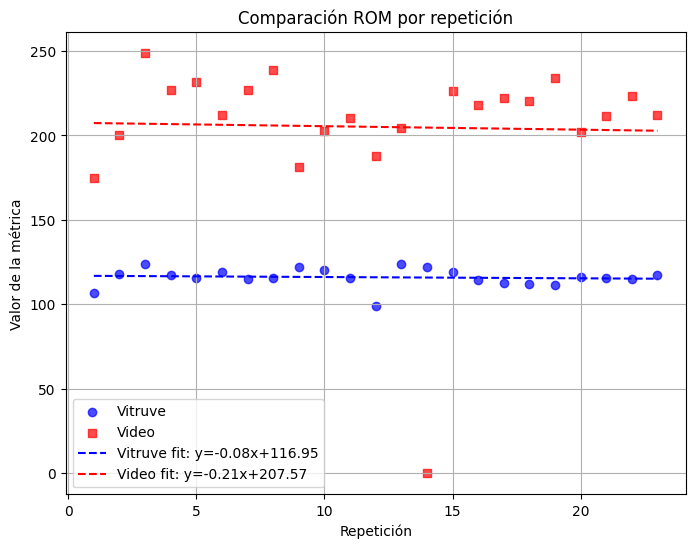

In [ ]:
plot_comparison_by_rep(swing_merge_df, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(swing_merge_df, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(swing_merge_df, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")

In [ ]:
df_vmed = swing_merge_df[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = swing_merge_df[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = swing_merge_df[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

Ratio VMED (Vitruve/Video) = 0.9019230769230767
Ratio VMAX (Vitruve/Video) = 1.031542699724518
Ratio ROM (Vitruve/Video) = 0.5657638222871211
